Compute mean connectivity from HCP7T dataset

In [1]:
import os

import numpy as np
import pandas as pd
import seaborn as sns
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.colors as colors

from glob import glob

In [2]:
tian_scale = 'S2'

lut_fpath = os.path.join('/Users/dsj3886/data_local/derivatives/',
                         f'atlas-custom_subcort-tian{tian_scale}_cort-aud-vis-prefrontal',
                         f'atlas-custom_subcort-tian{tian_scale}_cort-aud-vis-prefrontal_lut.tsv')

region_list = list(pd.read_csv(lut_fpath, sep='\t', header=None).iloc[:,1])

In [3]:
# Data preparation (all cortical ROIs to keep) 
AUDITORY_ROIS   = ['STGa', 'PP', 'HG', 'PT', 'STGp']
PREFRONTAL_ROIS = ['OFC', 'ACC', 'FMC', 'IFGt', 'IFGo']
CORTEX_ROIS     = AUDITORY_ROIS + PREFRONTAL_ROIS

# Display-only relabeling: the codes above stay unchanged (they must match the
# external atlas LUT / connectivity data); this is applied only when rendering
# text (plot titles, tick labels, annotations).
ROI_DISPLAY_NAMES = {'IFGo': 'ParsOp', 'IFGt': 'ParsTri'}

def _display_label(name):
    if len(name) > 2 and name[:2] in ('L-', 'R-'):
        return name[:2] + ROI_DISPLAY_NAMES.get(name[2:], name[2:])
    return ROI_DISPLAY_NAMES.get(name, name)


In [4]:
data_dir = os.path.join('/Users/dsj3886/data_local/derivatives/',
                        'HCP_7T_diffusion/msmt_csd_nthreads-1/')


STATS_OUT_DIR = 'stats_exports/no-gpexcl'
os.makedirs(STATS_OUT_DIR, exist_ok=True)

FIGURES_DIR = 'figures/no-gpexcl'
os.makedirs(FIGURES_DIR, exist_ok=True)

## Read in participant connectivity matrices

In [5]:
print(data_dir + 
      '/*/connectome_streamlines_alg-iFOD2_nsl-10mil/'+
                         'atlas-custom_subcort-tian{tian_scale}_cort-carpet_sift2-noscaling/'+
                         'streamlines_alg-iFOD2_nsl-10mil_connectome_sift2-noscaling.csv')

/Users/dsj3886/data_local/derivatives/HCP_7T_diffusion/msmt_csd_nthreads-1//*/connectome_streamlines_alg-iFOD2_nsl-10mil/atlas-custom_subcort-tian{tian_scale}_cort-carpet_sift2-noscaling/streamlines_alg-iFOD2_nsl-10mil_connectome_sift2-noscaling.csv


In [6]:
conn_files = sorted(glob(data_dir + 
                         '/*/connectome_streamlines_alg-iFOD2_nsl-10mil/'+
                         f'atlas-custom_subcort-tian{tian_scale}_cort-carpet_sift2-noscaling/'+
                         'streamlines_alg-iFOD2_nsl-10mil_connectome_sift2-noscaling.csv'))

# derive participant IDs directly from conn_files (preserves same order)
participants_with_files = sorted(list({os.path.basename(os.path.dirname(os.path.dirname(os.path.dirname(p)))) for p in conn_files}))


In [7]:
print(len(conn_files))

100


In [8]:
test_df = pd.read_csv(conn_files[0], header=None)
print(test_df)
print(len(test_df))


             0             1            2            3            4   \
0   7206.911588   2926.740649  2180.639044   889.796890    67.454874   
1   2926.740649   3960.332659   299.871718  1110.757816    63.926619   
2   2180.639044    299.871718  9126.612409  1447.897161    63.349411   
3    889.796890   1110.757816  1447.897161  2947.525646    38.055078   
4     67.454874     63.926619    63.349411    38.055078  8894.208278   
5    107.152501    197.563003    17.449642    93.113207  2833.272241   
6     14.704173      4.269951    37.085071    20.137785  3110.453647   
7     23.708305     27.598727    17.559512    41.262862   278.481873   
8     51.241972   3056.688341     4.607296    14.802656     0.000000   
9    551.218640   4357.850801    32.787043    39.882825    22.572189   
10   270.361598   1196.479019    21.535647    69.488868     0.167777   
11     7.427087    257.986364     4.312154     6.326887     0.000000   
12    85.741274    172.725782    11.255783    30.417490     0.00

In [9]:
num_regions = len(region_list)  # 54
conn_files_54 = [f for f in conn_files
                 if pd.read_csv(f, header=None).shape[0] == num_regions]

num_subjects = len(conn_files_54)
connmats_raw = np.zeros((num_subjects, num_regions, num_regions))
slcounts = np.zeros((num_regions, num_subjects))
list_df = []

for sx, matrix_fpath in enumerate(conn_files_54):
    sub_df = pd.read_csv(matrix_fpath, header=None)
    list_df.append(sub_df)
    connmats_raw[sx,:,:] = sub_df.to_numpy()
    slcounts[:,sx] = sub_df.to_numpy().sum(axis=0)

In [10]:
# --- Per-subject connectome normalisation ----------------------------------
# The connectome CSVs are RAW SIFT2-weighted streamline sums (tck2connectome
# run WITHOUT -scale_invnodevol). Each edge is normalised by:
#   (1) the subject's SIFT2 proportionality coefficient mu -> cross-subject scale
#   (2) the volume of the STRIATAL node only               -> connectivity density
#       C(striatum_i, cortex_j) = mu_s * raw_sum(i, j) / V_striatum(s, i)
# Striatal volumes come from each subject's own T1w/acpc-space parcellation
# (the same image passed to tck2connectome).

striatum_idx = np.array([i for i, r in enumerate(region_list)
                         if r.startswith(('aPUT', 'pPUT', 'aCAU', 'pCAU'))])

_subatlas_tmpl = ('/Users/dsj3886/data_local/derivatives/HCP_7T_diffusion/'
                  'atlas_space-sub/{sub}/sub-{sub}_'
                  f'atlas-custom_subcort-tian{tian_scale}_cort-carpet'
                  '_atlas_warp-standard2acpc_dc_space-T1w.nii.gz')
_mu_tmpl = ('/Users/dsj3886/data_local/derivatives/HCP_7T_diffusion/'
            'msmt_csd_nthreads-1/{sub}/'
            'sift2_mu_streamlines_alg-iFOD2_nsl-10mil.txt')

# subject IDs in the same order as connmats_raw (== conn_files_54)
subs_54 = [os.path.basename(os.path.dirname(os.path.dirname(os.path.dirname(f))))
           for f in conn_files_54]

mu = np.zeros(num_subjects)
striatal_vol_mm3 = np.zeros((num_subjects, num_regions))   # 0 outside striatum
for sx, sub in enumerate(subs_54):
    mu[sx] = float(np.loadtxt(_mu_tmpl.format(sub=sub)))
    seg_img = nib.load(_subatlas_tmpl.format(sub=sub))
    seg = np.asarray(seg_img.dataobj)
    vox_mm3 = float(np.prod(seg_img.header.get_zooms()[:3]))
    for idx in striatum_idx:
        striatal_vol_mm3[sx, idx] = np.count_nonzero(seg == idx + 1) * vox_mm3

print(f'mu: mean={mu.mean():.4g}  range=[{mu.min():.4g}, {mu.max():.4g}]')
print('striatal volume (mm^3), across-subject mean (SD):')
for idx in striatum_idx:
    v = striatal_vol_mm3[:, idx]
    print(f'  {region_list[idx]:9s} {v.mean():8.1f} ({v.std():6.1f})')

_sv = striatal_vol_mm3[:, striatum_idx]
if (_sv == 0).any():
    print(f'WARNING: {(_sv == 0).sum()} zero striatal volume(s) -> those edges = nan')

# scale the whole matrix by mu; divide the striatal ROWS by their own volume
inv_vol = np.ones((num_subjects, num_regions))
with np.errstate(divide='ignore'):
    inv_vol[:, striatum_idx] = np.where(_sv > 0, 1.0 / _sv, np.nan)

connmats_corrected = connmats_raw * mu[:, None, None] * inv_vol[:, :, None]


mu: mean=0.001095  range=[0.0007928, 0.001497]
striatal volume (mm^3), across-subject mean (SD):
  aPUT-lh     2350.9 ( 327.0)
  pPUT-lh     2375.7 ( 290.8)
  aCAU-lh     1505.9 ( 288.3)
  pCAU-lh      842.5 ( 130.3)
  aPUT-rh     2354.3 ( 309.5)
  pPUT-rh     2660.2 ( 305.6)
  aCAU-rh     1542.8 ( 292.5)
  pCAU-rh      808.9 ( 159.2)


In [11]:
# Drop subjects with a zero-volume striatal ROI. A zero volume makes that
# subject's connectivity NaN for that ROI (cell above); AnovaRM aggregates
# cells with np.mean, which does NOT skip NaN, so a single bad cell corrupts
# that subject's entire design row (LinAlgError: SVD did not converge).
_bad = np.where((_sv == 0).any(axis=1))[0]
if len(_bad):
    _bad_subs = [subs_54[i] for i in _bad]
    print(f'Dropping {len(_bad)} subject(s) with a zero-volume striatal ROI: {_bad_subs}')
    _keep = np.array([i for i in range(num_subjects) if i not in set(_bad)])
    connmats_corrected = connmats_corrected[_keep]
    subs_54 = [subs_54[i] for i in _keep]
    mu = mu[_keep]
    striatal_vol_mm3 = striatal_vol_mm3[_keep]
    num_subjects = len(subs_54)

connmats = connmats_corrected


In [12]:
np.shape(connmats)

(100, 54, 54)

In [13]:
# check the streamline count matrix (region x subject)
slcounts

array([[ 40785.74821794,  35894.14756818,  36522.27827185, ...,
         34770.70381761,  36911.46632458,  42888.28348294],
       [ 57036.03131111,  48354.45951775,  51293.88481334, ...,
         48735.9578224 ,  52115.10300376,  59980.95118681],
       [ 25369.18850191,  17406.95383771,  14696.15703639, ...,
         15105.03527857,  30020.30560711,  19436.29200229],
       ...,
       [118349.33073521, 121994.43375887,  78352.98838741, ...,
         78695.11315507,  98810.72286119, 100893.5526569 ],
       [ 15155.93061075,  20579.48272069,  28019.71068372, ...,
         11587.20724113,  15613.30551444,  10256.86989315],
       [181099.35063294, 126839.30125006, 130443.81948979, ...,
         97000.01784281,  73978.32680383, 106814.40069577]])

In [14]:
slcounts[0,:]

array([40785.74821794, 35894.14756818, 36522.27827185, 41964.17139184,
       36654.12061669, 31462.25718579, 36198.15094261, 34942.58113354,
       32301.3743801 , 49020.28650255, 35963.93362004, 52398.64442559,
       28468.92672901, 41166.18433082, 28318.32347953, 41036.9703746 ,
       56231.37871233, 38018.94458967, 30967.30040349, 39036.80150783,
       21453.89237523, 40612.78600635, 38001.64022021, 41543.50599718,
       35648.79508653, 36125.21833314, 36799.12004633, 45160.21676526,
       41411.37873355, 46186.73323992, 39473.65154149, 32402.05997716,
       44185.7853353 , 29215.30182542, 26935.40469021, 23387.92837952,
       37721.22212318, 37550.2031706 , 27847.93415532, 33229.89342758,
       34237.0822839 , 40853.90129097, 34698.8342609 , 32344.3982185 ,
       41611.58680525, 31545.05087712, 32092.46716855, 38542.67707494,
       36851.65462027, 26206.68621922, 43901.81019944, 36857.40658535,
       40015.82976545, 50036.59799241, 29724.02671248, 25887.56827386,
      

## Compute mean streamline count per ROI

In [15]:
# compute the mean streamline count per IC subdivision
mean_slcount = slcounts.mean(axis=1)
print(mean_slcount)
print(mean_slcount.shape)

[ 36473.87112237  52157.59219069  21263.76697717  18283.41626267
  30404.09175883  57295.18836699  17781.2721054   18536.18189865
  32645.6717488   48843.72200473  57655.46646706  29495.03548725
  45051.76488744  31179.59617972  43280.0656333   50425.32383446
  18357.995934    56315.34644924 223289.24548082 251247.86035405
 174622.46868897 153726.44080963 129776.35867288 146260.56818267
  43862.08684849  47033.43920168  58535.45840705  52737.52780706
 256476.49143175 287863.7198335   10357.77125983   6354.84027252
  94013.26411564  91710.72161706  62039.61705397  67713.31608656
  62742.08858847  61442.76370268  47007.0202896   36227.32297974
 218623.92436891 128193.14342689  59666.81589621  67737.48811234
 116648.55031586  22294.17151558 175933.05418053 191103.11594235
 120998.66978368  62620.41719008  72475.92282694 104979.18061547
  17724.01821028 125246.56411865]
(54,)


In [16]:
mean_connmat = connmats.mean(axis=0)

print(mean_connmat)
print(mean_connmat.shape)

[[1.64304289e-03 9.97168429e-04 6.37294887e-04 ... 8.64179627e-08
  2.98207871e-08 5.39552735e-09]
 [9.84408758e-04 1.62127047e-03 7.80088085e-05 ... 5.82874969e-08
  1.69400424e-06 1.21729013e-06]
 [1.01649267e-03 1.25683253e-04 3.45519900e-03 ... 3.66910732e-07
  1.52951357e-07 0.00000000e+00]
 ...
 [1.99657156e-04 1.31576167e-04 4.78990506e-04 ... 5.16643085e+01
  1.11684422e-01 1.53212007e+01]
 [6.77061922e-05 3.73397296e-03 2.27545906e-04 ... 1.11684422e-01
  2.12053306e+00 2.58191906e+00]
 [1.09837393e-05 2.83255090e-03 0.00000000e+00 ... 1.53212007e+01
  2.58191906e+00 6.69422364e+01]]
(54, 54)


In [17]:

# add ROI names to df
mean_df = pd.DataFrame(mean_connmat, columns=region_list)
mean_df.insert(0, 'seed', region_list)
mean_df.insert(0, 'mean_slcount', mean_slcount)


In [18]:
mean_df

,mean_slcount,seed,aPUT-lh,pPUT-lh,aCAU-lh,pCAU-lh,aPUT-rh,pPUT-rh,aCAU-rh,pCAU-rh,...,L-OccFus,L-SupraCalc,L-OccPole,R-LOCsup,R-LOCinf,R-IntraCalc,R-TempOccFus,R-OccFus,R-SupraCalc,R-OccPole
0,36473.871122,aPUT-lh,0.001643,0.000997,0.000637,0.000155,0.000010,0.000009,0.000011,0.000008,...,3.424357e-04,1.013572e-05,8.063260e-05,4.940542e-09,3.625136e-08,3.522615e-07,1.991733e-06,8.641796e-08,2.982079e-08,5.395527e-09
1,52157.592191,pPUT-lh,0.000984,0.001621,0.000078,0.000386,0.000008,0.000023,0.000004,0.000011,...,4.487585e-04,2.991757e-05,1.277624e-03,2.146717e-06,1.438012e-09,2.068236e-06,1.987587e-06,5.828750e-08,1.694004e-06,1.217290e-06
2,21263.766977,aCAU-lh,0.001016,0.000126,0.003455,0.001056,0.000015,0.000008,0.000062,0.000022,...,2.116890e-05,4.117509e-06,1.424352e-08,1.535994e-07,6.132651e-09,1.220228e-06,7.227050e-07,3.669107e-07,1.529514e-07,0.000000e+00
3,18283.416263,pCAU-lh,0.000442,0.001109,0.001865,0.002994,0.000022,0.000055,0.000046,0.000113,...,8.359134e-06,3.681133e-06,1.200516e-05,1.255681e-06,4.029601e-08,3.830027e-07,8.532141e-07,1.549866e-08,2.470407e-07,9.087004e-09
4,30404.091759,aPUT-rh,0.000010,0.000008,0.000009,0.000008,0.002295,0.001172,0.000553,0.000107,...,7.886138e-07,3.964755e-08,2.887436e-09,3.852130e-04,1.120887e-04,1.714438e-04,4.427509e-05,4.531332e-04,7.215602e-06,1.094238e-04
5,57295.188367,pPUT-rh,0.000008,0.000021,0.000005,0.000018,0.001037,0.001522,0.000082,0.000355,...,5.259295e-08,3.514534e-06,1.833593e-07,2.349763e-03,2.614645e-04,1.710953e-04,8.019694e-05,4.969697e-04,1.528887e-05,1.184108e-03
6,17781.272105,aCAU-rh,0.000016,0.000007,0.000060,0.000025,0.000862,0.000143,0.003259,0.001704,...,2.441895e-07,2.578649e-08,0.000000e+00,2.085864e-05,3.191685e-06,8.510156e-06,7.745288e-06,2.232838e-05,1.109640e-06,6.261746e-08
7,18536.181899,pCAU-rh,0.000022,0.000031,0.000040,0.000118,0.000321,0.001192,0.003244,0.004169,...,1.023633e-08,1.174671e-07,2.199387e-09,2.874174e-04,2.278552e-05,6.709971e-06,6.588118e-06,5.606491e-06,8.448376e-07,6.803725e-06
8,32645.671749,L-HG,0.099969,3.393499,0.005772,0.007539,0.000029,0.003196,0.000185,0.000382,...,9.075010e-03,8.518786e-03,2.716602e-02,3.230184e-03,4.251913e-06,1.004520e-03,1.285166e-04,4.639110e-06,1.078459e-03,1.397203e-05
9,48843.722005,L-PP,0.720985,4.076920,0.051498,0.062300,0.003533,0.004694,0.002287,0.002018,...,8.962852e-01,6.312319e-02,1.650897e+00,2.068347e-04,0.000000e+00,2.485733e-03,3.197862e-04,4.109199e-06,1.202881e-03,1.708859e-03


In [19]:

# save the mean data
out_dir = os.path.join(data_dir, 'group_plots_prefrontal')
out_fpath = os.path.join(out_dir, 'pd_mean_connectivity_scale-mu-strivol.txt')
os.makedirs(out_dir, exist_ok=True)
mean_df.to_csv(out_fpath, sep='\t', index=False)


#### Value distribution

No low-value threshold is applied. See the *Plot distributions* section for the distribution of the striatum×cortex edges that enter the statistics.

### Plot distributions

In [20]:
connmats.shape

(100, 54, 54)

36800 striatum x cortex edges  |  20.9% exactly zero  |  0.0% nan

all edges:
count    3.680000e+04
mean     3.117931e-04
std      9.197218e-04
min      0.000000e+00
5%       0.000000e+00
25%      3.502643e-07
50%      1.156185e-05
75%      1.534003e-04
95%      1.785892e-03
99%      5.062511e-03
max      1.454301e-02
dtype: float64

non-zero edges:
count    2.911000e+04
mean     3.941596e-04
std      1.018277e-03
min      4.302132e-08
5%       3.385845e-07
25%      3.982635e-06
50%      3.562533e-05
75%      2.552553e-04
95%      2.189260e-03
99%      5.590524e-03
max      1.454301e-02
dtype: float64


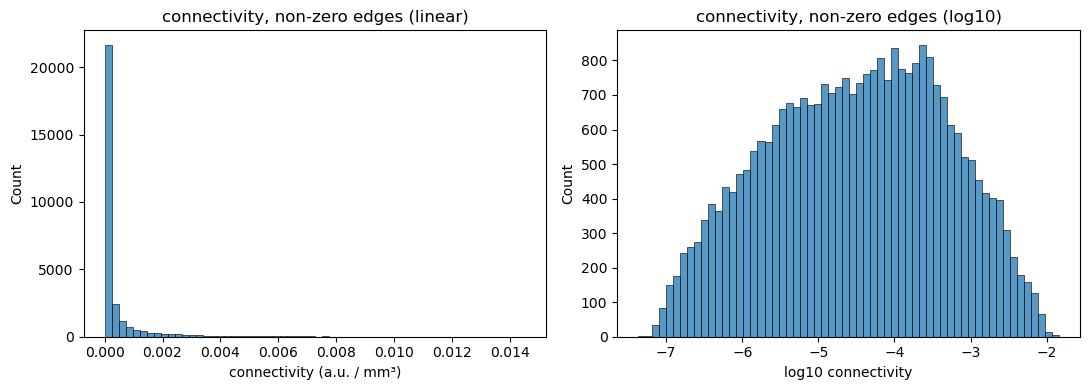

In [21]:
# Distribution of the striatum x cortex connectivity values that enter the stats
_ctx = [i for i, r in enumerate(region_list) if r.startswith(('L-', 'R-'))]
block = connmats[:, striatum_idx][:, :, _ctx].ravel()   # subjects x striatum x cortex
block_nz = block[np.isfinite(block) & (block > 0)]

print(f'{block.size} striatum x cortex edges  |  '
      f'{np.mean(block == 0) * 100:.1f}% exactly zero  |  '
      f'{np.mean(~np.isfinite(block)) * 100:.1f}% nan')
print('\nall edges:')
print(pd.Series(block).describe(percentiles=[.05, .25, .5, .75, .95, .99]))
print('\nnon-zero edges:')
print(pd.Series(block_nz).describe(percentiles=[.05, .25, .5, .75, .95, .99]))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(block_nz, bins=60, ax=axes[0])
axes[0].set(title='connectivity, non-zero edges (linear)',
            xlabel='connectivity (a.u. / mm³)')
sns.histplot(np.log10(block_nz), bins=60, ax=axes[1])
axes[1].set(title='connectivity, non-zero edges (log10)', xlabel='log10 connectivity')
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'distribution_connectivity_striatum-cortex.svg'))


## Connectivity plots

In [22]:
num_participants = len(connmats)
print(f'Participants entering analysis: N = {num_participants}')

# Account for subjects not in the analysis. run_subject.sh skips any subject
# whose subject-space atlas has < 54 regions (warped before the prefrontal ROIs
# were added), so those have no _sift2-noscaling connectome. Check the atlas
# files directly for a complete picture.
_atlas_dir = '/Users/dsj3886/data_local/derivatives/HCP_7T_diffusion/atlas_space-sub'
_atlas_tail = (f'_atlas-custom_subcort-tian{tian_scale}_cort-carpet'
               '_atlas_warp-standard2acpc_dc_space-T1w.nii.gz')
_atlas_files = sorted(glob(os.path.join(_atlas_dir, '*', f'sub-*{_atlas_tail}')))
_by_regions = {}
for _a in _atlas_files:
    _sub = os.path.basename(_a).split('_')[0].replace('sub-', '')
    _n = int(np.asarray(nib.load(_a).dataobj).max())
    _by_regions.setdefault(_n, []).append(_sub)

print(f'\nsubject-space atlases found: {len(_atlas_files)}')
for _n, _subs in sorted(_by_regions.items()):
    _flag = 'analysed' if _n == num_regions else 'EXCLUDED (re-warp with 54-region atlas)'
    print(f'  {_n:>2}-region: {len(_subs):>3} subjects   <- {_flag}')
_excluded = sorted(s for n, ss in _by_regions.items() if n != num_regions for s in ss)
if _excluded:
    print(f'\nexcluded: {" ".join(_excluded)}')


Participants entering analysis: N = 100

subject-space atlases found: 175
  32-region:  75 subjects   <- EXCLUDED (re-warp with 54-region atlas)
  54-region: 100 subjects   <- analysed

excluded: 318637 320826 330324 346137 352738 360030 365343 380036 381038 385046 389357 393247 395756 397760 401422 406836 412528 429040 436845 463040 467351 525541 541943 547046 562345 572045 573249 581450 585256 601127 617748 627549 638049 644246 654552 671855 680957 690152 706040 724446 725751 732243 745555 751550 757764 765864 770352 771354 782561 783462 789373 814649 818859 825048 826353 833249 861456 871762 872764 878776 878877 898176 899885 901139 901442 905147 910241 926862 927359 942658 943862 951457 958976 966975 971160


In [23]:
plot_df = mean_df.iloc[:, 2:]


In [24]:
plot_df

,aPUT-lh,pPUT-lh,aCAU-lh,pCAU-lh,aPUT-rh,pPUT-rh,aCAU-rh,pCAU-rh,L-HG,L-PP,...,L-OccFus,L-SupraCalc,L-OccPole,R-LOCsup,R-LOCinf,R-IntraCalc,R-TempOccFus,R-OccFus,R-SupraCalc,R-OccPole
0,0.001643,0.000997,0.000637,0.000155,0.000010,0.000009,0.000011,0.000008,4.238498e-05,0.000306,...,3.424357e-04,1.013572e-05,8.063260e-05,4.940542e-09,3.625136e-08,3.522615e-07,1.991733e-06,8.641796e-08,2.982079e-08,5.395527e-09
1,0.000984,0.001621,0.000078,0.000386,0.000008,0.000023,0.000004,0.000011,1.438898e-03,0.001727,...,4.487585e-04,2.991757e-05,1.277624e-03,2.146717e-06,1.438012e-09,2.068236e-06,1.987587e-06,5.828750e-08,1.694004e-06,1.217290e-06
2,0.001016,0.000126,0.003455,0.001056,0.000015,0.000008,0.000062,0.000022,3.760786e-06,0.000036,...,2.116890e-05,4.117509e-06,1.424352e-08,1.535994e-07,6.132651e-09,1.220228e-06,7.227050e-07,3.669107e-07,1.529514e-07,0.000000e+00
3,0.000442,0.001109,0.001865,0.002994,0.000022,0.000055,0.000046,0.000113,9.107254e-06,0.000078,...,8.359134e-06,3.681133e-06,1.200516e-05,1.255681e-06,4.029601e-08,3.830027e-07,8.532141e-07,1.549866e-08,2.470407e-07,9.087004e-09
4,0.000010,0.000008,0.000009,0.000008,0.002295,0.001172,0.000553,0.000107,1.210109e-08,0.000001,...,7.886138e-07,3.964755e-08,2.887436e-09,3.852130e-04,1.120887e-04,1.714438e-04,4.427509e-05,4.531332e-04,7.215602e-06,1.094238e-04
5,0.000008,0.000021,0.000005,0.000018,0.001037,0.001522,0.000082,0.000355,1.246334e-06,0.000002,...,5.259295e-08,3.514534e-06,1.833593e-07,2.349763e-03,2.614645e-04,1.710953e-04,8.019694e-05,4.969697e-04,1.528887e-05,1.184108e-03
6,0.000016,0.000007,0.000060,0.000025,0.000862,0.000143,0.003259,0.001704,1.242711e-07,0.000001,...,2.441895e-07,2.578649e-08,0.000000e+00,2.085864e-05,3.191685e-06,8.510156e-06,7.745288e-06,2.232838e-05,1.109640e-06,6.261746e-08
7,0.000022,0.000031,0.000040,0.000118,0.000321,0.001192,0.003244,0.004169,4.969208e-07,0.000002,...,1.023633e-08,1.174671e-07,2.199387e-09,2.874174e-04,2.278552e-05,6.709971e-06,6.588118e-06,5.606491e-06,8.448376e-07,6.803725e-06
8,0.099969,3.393499,0.005772,0.007539,0.000029,0.003196,0.000185,0.000382,1.064396e+01,5.193631,...,9.075010e-03,8.518786e-03,2.716602e-02,3.230184e-03,4.251913e-06,1.004520e-03,1.285166e-04,4.639110e-06,1.078459e-03,1.397203e-05
9,0.720985,4.076920,0.051498,0.062300,0.003533,0.004694,0.002287,0.002018,5.193631e+00,10.731314,...,8.962852e-01,6.312319e-02,1.650897e+00,2.068347e-04,0.000000e+00,2.485733e-03,3.197862e-04,4.109199e-06,1.202881e-03,1.708859e-03


In [25]:
roi_dir = os.path.join('/Users/dsj3886/data_local/derivatives/',
                       'atlas-custom_subcort-tians2_cort-aud-vis-prefrontal')

In [26]:
print(roi_dir)

/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-prefrontal


In [27]:
cau_lh_list = sorted(glob(roi_dir+'/*CAU*lh.nii.gz'))
put_lh_list = sorted(glob(roi_dir+'/*PUT*lh.nii.gz'))
cau_rh_list = sorted(glob(roi_dir+'/*CAU*rh.nii.gz'))
put_rh_list = sorted(glob(roi_dir+'/*PUT*rh.nii.gz'))

cp_list = cau_lh_list + put_lh_list + cau_rh_list + put_rh_list

In [28]:
cp_list

['/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-prefrontal/atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal_aCAU-lh.nii.gz',
 '/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-prefrontal/atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal_pCAU-lh.nii.gz',
 '/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-prefrontal/atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal_aPUT-lh.nii.gz',
 '/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-prefrontal/atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal_pPUT-lh.nii.gz',
 '/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-prefrontal/atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal_aCAU-rh.nii.gz',
 '/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-prefrontal/atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal_pCAU-rh.nii.gz',
 '/Users/dsj3886/data_local/deriva

In [29]:
cp_roi_list = [os.path.basename(x).split('.')[0].split('prefrontal_')[1] for x in cp_list]

print(cp_roi_list)


['aCAU-lh', 'pCAU-lh', 'aPUT-lh', 'pPUT-lh', 'aCAU-rh', 'pCAU-rh', 'aPUT-rh', 'pPUT-rh']


In [30]:
cp_sl_list = []
for rx, roi_name in enumerate(cp_roi_list):
    print(roi_name)
    roi_row = mean_df[mean_df.seed==roi_name]
    print(roi_row)

    roi_row_corrected = roi_row.iloc[0,2:].to_numpy() 
    print(roi_row_corrected)

    cp_sl_list.append(roi_row_corrected)

aCAU-lh
   mean_slcount     seed   aPUT-lh   pPUT-lh   aCAU-lh   pCAU-lh   aPUT-rh  \
2  21263.766977  aCAU-lh  0.001016  0.000126  0.003455  0.001056  0.000015   

    pPUT-rh   aCAU-rh   pCAU-rh  ...  L-OccFus  L-SupraCalc     L-OccPole  \
2  0.000008  0.000062  0.000022  ...  0.000021     0.000004  1.424352e-08   

       R-LOCsup      R-LOCinf  R-IntraCalc  R-TempOccFus      R-OccFus  \
2  1.535994e-07  6.132651e-09     0.000001  7.227050e-07  3.669107e-07   

    R-SupraCalc  R-OccPole  
2  1.529514e-07        0.0  

[1 rows x 56 columns]
[0.0010164926701838105 0.00012568325311176787 0.00345519899850919
 0.00105607667024168 1.464377135518187e-05 8.474229173687159e-06
 6.200258795591388e-05 2.183094489291583e-05 3.7607863985255095e-06
 3.563792805775597e-05 1.0883197746607436e-05 2.107559025813781e-06
 1.5687798313934791e-06 1.624001939972526e-07 1.5394487318682533e-06
 4.099781141412161e-07 1.3322758180196e-08 8.417000942400696e-08
 0.005320279554518042 0.00043789204711190325 0.00

In [31]:
cs_df = pd.DataFrame(data=cp_sl_list, 
                          columns=region_list,
                          index=cp_roi_list)
print(cs_df)

          aPUT-lh   pPUT-lh   aCAU-lh   pCAU-lh   aPUT-rh   pPUT-rh   aCAU-rh  \
aCAU-lh  0.001016  0.000126  0.003455  0.001056  0.000015  0.000008  0.000062   
pCAU-lh  0.000442  0.001109  0.001865  0.002994  0.000022  0.000055  0.000046   
aPUT-lh  0.001643  0.000997  0.000637  0.000155  0.000010  0.000009  0.000011   
pPUT-lh  0.000984  0.001621  0.000078  0.000386  0.000008  0.000023  0.000004   
aCAU-rh  0.000016  0.000007  0.000060  0.000025  0.000862  0.000143  0.003259   
pCAU-rh  0.000022  0.000031  0.000040  0.000118  0.000321  0.001192  0.003244   
aPUT-rh  0.000010  0.000008  0.000009  0.000008  0.002295  0.001172  0.000553   
pPUT-rh  0.000008  0.000021  0.000005  0.000018  0.001037  0.001522  0.000082   

          pCAU-rh          L-HG      L-PP  ...      L-OccFus   L-SupraCalc  \
aCAU-lh  0.000022  3.760786e-06  0.000036  ...  2.116890e-05  4.117509e-06   
pCAU-lh  0.000113  9.107254e-06  0.000078  ...  8.359134e-06  3.681133e-06   
aPUT-lh  0.000008  4.238498e-05  0.0

In [32]:
region_list

['aPUT-lh',
 'pPUT-lh',
 'aCAU-lh',
 'pCAU-lh',
 'aPUT-rh',
 'pPUT-rh',
 'aCAU-rh',
 'pCAU-rh',
 'L-HG',
 'L-PP',
 'L-PT',
 'L-STGa',
 'L-STGp',
 'R-HG',
 'R-PP',
 'R-PT',
 'R-STGa',
 'R-STGp',
 'L-FP',
 'R-FP',
 'L-SFG',
 'R-SFG',
 'L-MFG',
 'R-MFG',
 'L-IFGt',
 'R-IFGt',
 'L-IFGo',
 'R-IFGo',
 'L-PreCG',
 'R-PreCG',
 'L-FMC',
 'R-FMC',
 'L-PCG',
 'R-PCG',
 'L-ACC',
 'R-ACC',
 'L-OFC',
 'R-OFC',
 'L-FO',
 'R-FO',
 'L-LOCsup',
 'L-LOCinf',
 'L-IntraCalc',
 'L-TempOccFus',
 'L-OccFus',
 'L-SupraCalc',
 'L-OccPole',
 'R-LOCsup',
 'R-LOCinf',
 'R-IntraCalc',
 'R-TempOccFus',
 'R-OccFus',
 'R-SupraCalc',
 'R-OccPole']

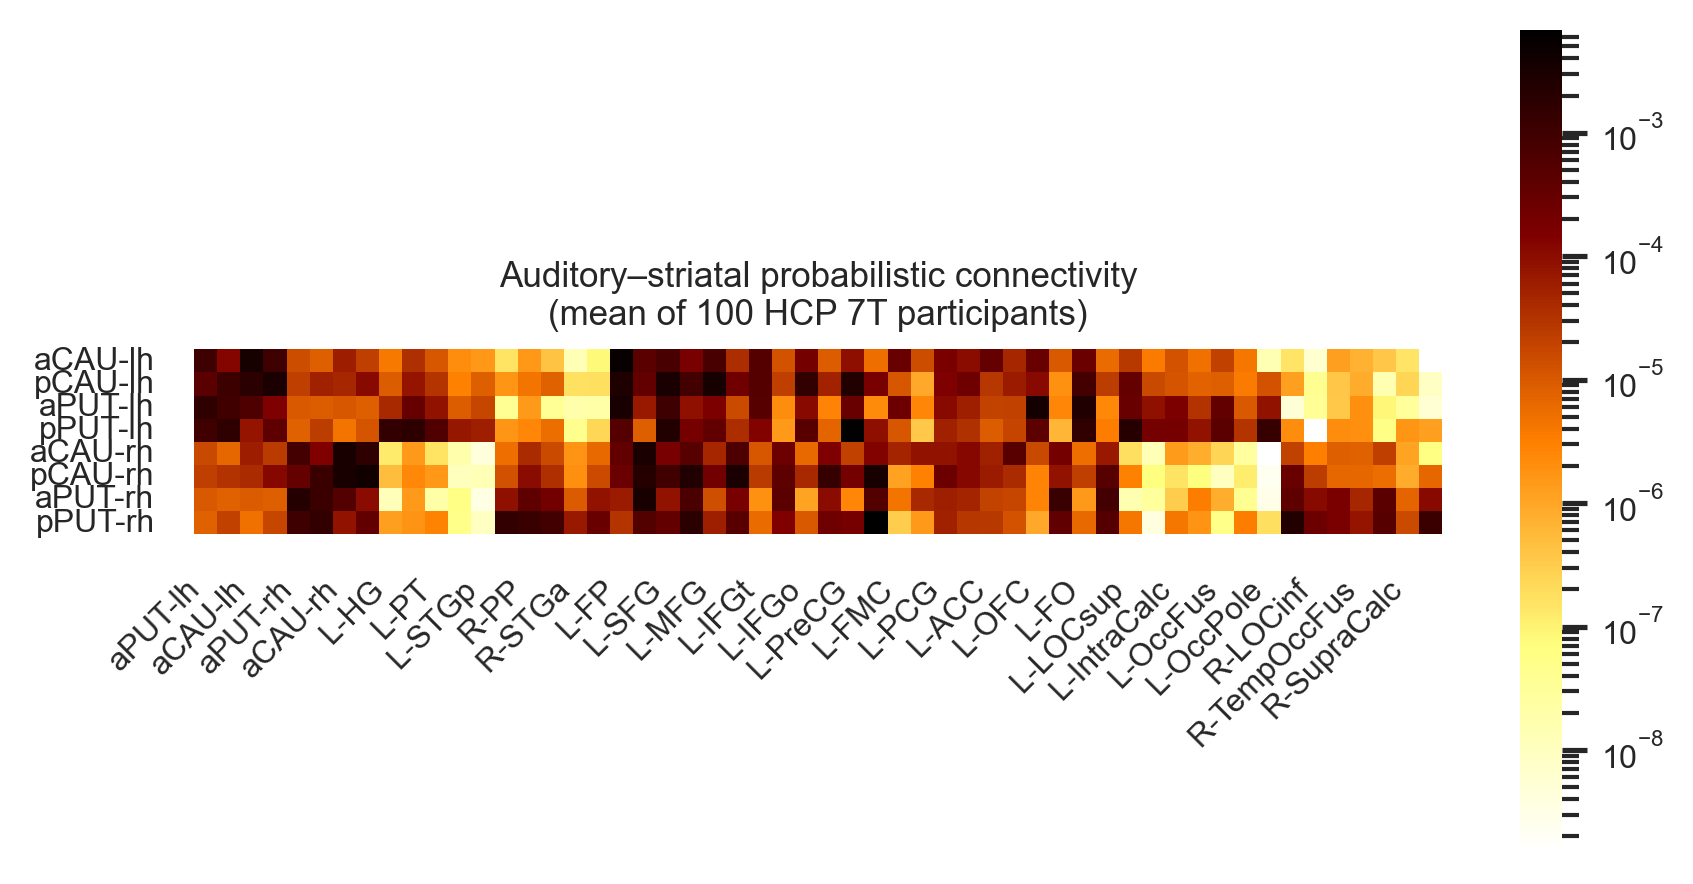

In [33]:
df_max = cs_df.to_numpy().max()

sns.set(font_scale=.7)
sns.set_style("white")

f, ax = plt.subplots(1,1,figsize=(6,3), dpi=300)

sns.heatmap(cs_df, ax=ax, cmap="afmhot_r",
            norm=colors.LogNorm(vmin=np.nanmin(cs_df.values[cs_df.values > 0]), vmax=df_max),
            square=True)
ax.set_title(f'Auditory–striatal probabilistic connectivity\n(mean of {num_participants} HCP 7T participants)');
#ax.tick_params(rotation=45, ha='right');
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

#sns.heatmap(right_cs_df, ax=ax[1], cmap="afmhot_r",
#            norm=colors.LogNorm(vmin=np.nanmin(cs_df.values[cs_df.values > 0]), vmax=df_max),)
#ax[1].tick_params(rotation=45);
#ax[1].set_title('Right hemisphere auditory–striatal probabilistic connectivity');
f.tight_layout()

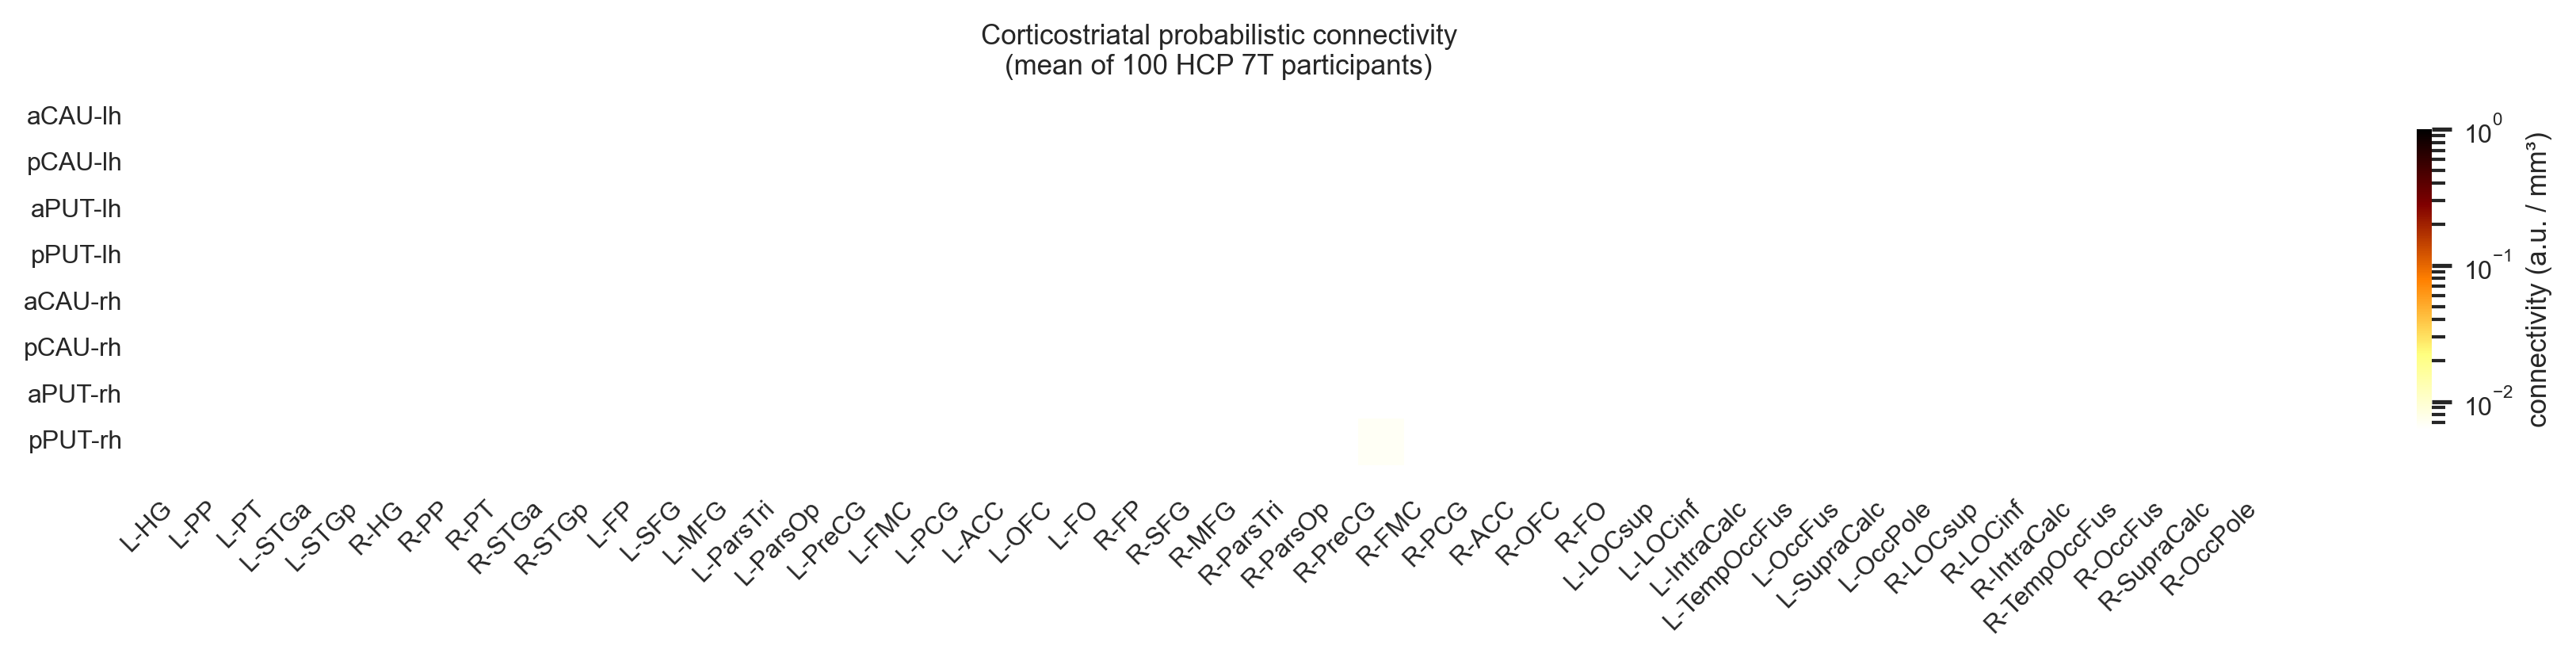

In [34]:
cortical_cols = [r for r in cs_df.columns if r.startswith(('L-', 'R-'))]

# Prefrontal ROIs were added with alternating L/R pairs; regroup to L-all then R-all
_pfc_base = {'FP', 'SFG', 'MFG', 'IFGt', 'IFGo', 'PreCG', 'FMC', 'PCG', 'ACC', 'OFC', 'FO'}
pfc_cols  = [c for c in cortical_cols if c[2:] in _pfc_base]
pfc_start = cortical_cols.index(pfc_cols[0])
pfc_end   = cortical_cols.index(pfc_cols[-1]) + 1

reordered = (cortical_cols[:pfc_start]
             + [c for c in pfc_cols if c.startswith('L-')]
             + [c for c in pfc_cols if c.startswith('R-')]
             + cortical_cols[pfc_end:])

cs_df_cortical = cs_df[reordered]
cs_df_cortical_display = cs_df_cortical.copy()
cs_df_cortical_display.columns = [_display_label(c) for c in cs_df_cortical_display.columns]

df_max = cs_df_cortical.to_numpy().max()

sns.set(font_scale=.7)
sns.set_style("white")

f, ax = plt.subplots(1, 1, figsize=(12, 3), dpi=300)

sns.heatmap(cs_df_cortical_display, ax=ax, cmap="afmhot_r",
            cbar_kws={'label': 'connectivity (a.u. / mm³)', 'shrink': 0.5},
            norm=colors.LogNorm(vmin=1, vmax=df_max),
            square=True)
ax.set_title(f'Corticostriatal probabilistic connectivity\n(mean of {num_participants} HCP 7T participants)')
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

f.savefig(os.path.join(FIGURES_DIR, 'heatmap_mean-streamlines_all-regions.svg'))
f.tight_layout()


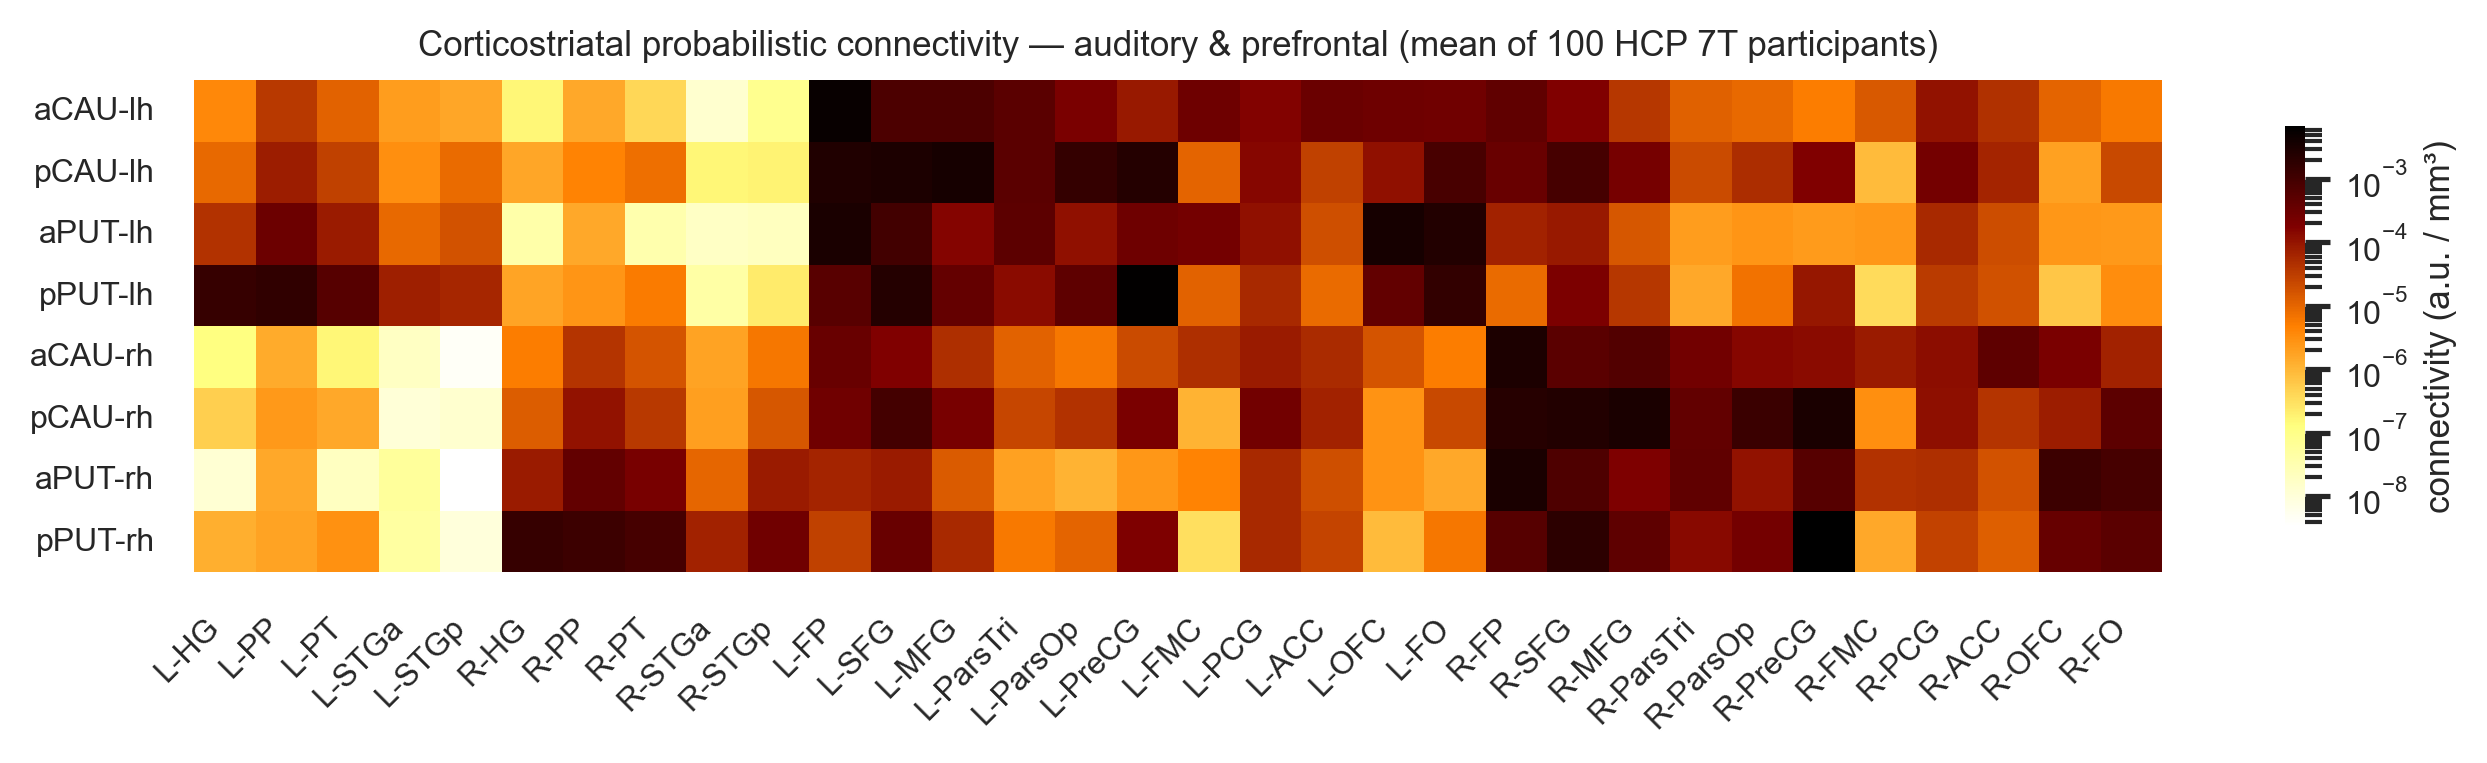

In [35]:
_aud_base = {'HG', 'PP', 'PT', 'STGa', 'STGp'}
no_vis_cols = [c for c in reordered if c[2:] in (_aud_base | _pfc_base)]
cs_df_no_vis = cs_df[no_vis_cols]
cs_df_no_vis_display = cs_df_no_vis.copy()
cs_df_no_vis_display.columns = [_display_label(c) for c in cs_df_no_vis_display.columns]

df_max_nov = cs_df_no_vis.to_numpy().max()

f2, ax2 = plt.subplots(1, 1, figsize=(9, 3), dpi=300)

sns.heatmap(cs_df_no_vis_display, ax=ax2, cmap="afmhot_r",
            cbar_kws={'label': 'connectivity (a.u. / mm³)', 'shrink': 0.5},
            norm=colors.LogNorm(vmin=np.nanmin(cs_df_no_vis.values[cs_df_no_vis.values > 0]), vmax=df_max_nov),
            square=True)
ax2.set_title(f'Corticostriatal probabilistic connectivity — auditory & prefrontal (mean of {num_participants} HCP 7T participants)')
plt.setp(ax2.get_xticklabels(), rotation=45, ha="right")

f.savefig(os.path.join(FIGURES_DIR, 'heatmap_mean-streamlines_auditory-prefrontal-regions.svg'))
f2.tight_layout()


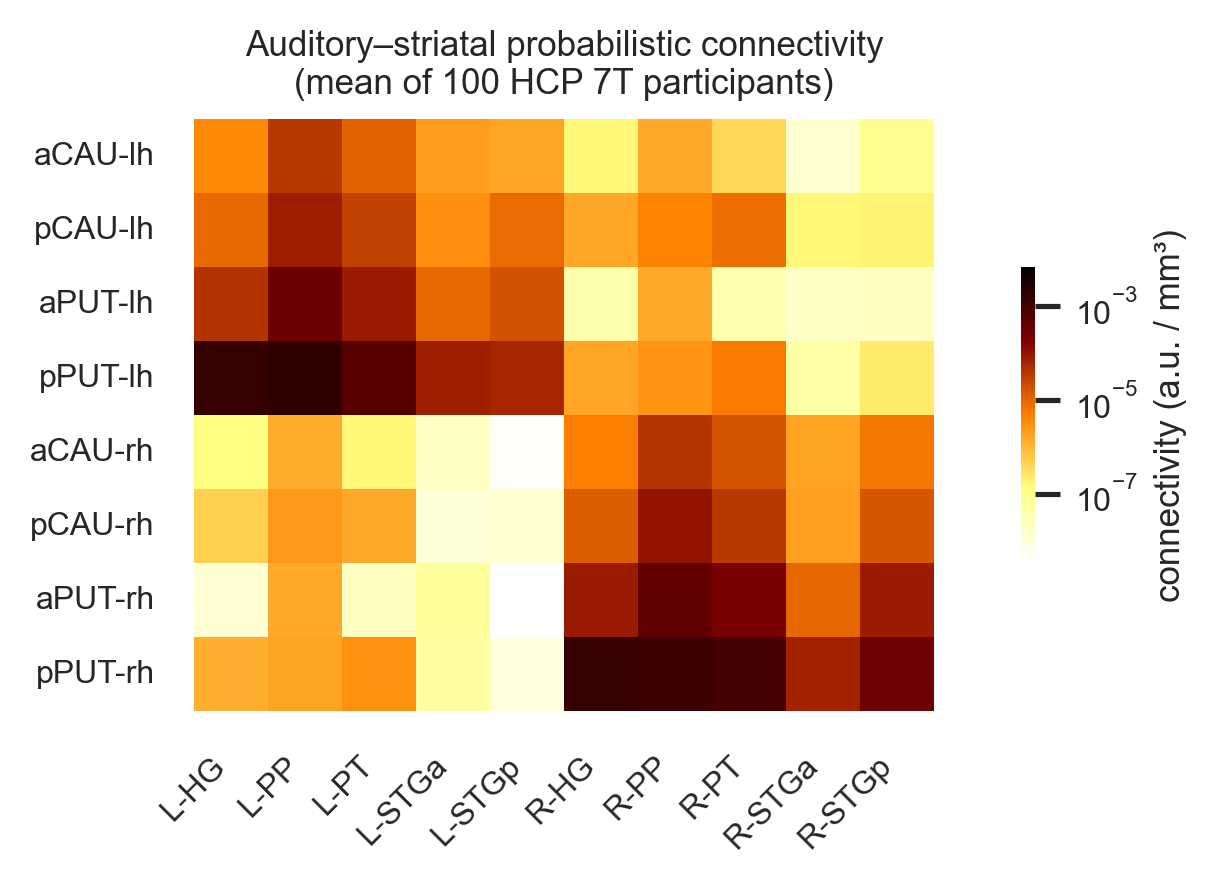

In [36]:
df_max = cs_df.to_numpy().max()
cs_df_aud_display = cs_df.iloc[:,8:18].copy()
cs_df_aud_display.columns = [_display_label(c) for c in cs_df_aud_display.columns]

sns.set(font_scale=.7)
sns.set_style("white")

f, ax = plt.subplots(1,1,figsize=(6,3), dpi=300)

sns.heatmap(cs_df_aud_display, ax=ax, cmap="afmhot_r",
            norm=colors.LogNorm(vmin=np.nanmin(cs_df.iloc[:, 8:18].values[cs_df.iloc[:, 8:18].values > 0]), vmax=df_max),
            cbar_kws={'label': 'connectivity (a.u. / mm³)', 'shrink': 0.5},
            square=True)
ax.set_title(f'Auditory–striatal probabilistic connectivity\n(mean of {num_participants} HCP 7T participants)');
#ax.tick_params(rotation=45, ha='right');
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

#sns.heatmap(right_cs_df, ax=ax[1], cmap="afmhot_r",
#            norm=colors.LogNorm(vmin=np.nanmin(cs_df.iloc[:, 8:18].values[cs_df.iloc[:, 8:18].values > 0]), vmax=df_max),)
#ax[1].tick_params(rotation=45);
#ax[1].set_title('Right hemisphere auditory–striatal probabilistic connectivity');

f.savefig(os.path.join(FIGURES_DIR, 'heatmap_mean-streamlines_auditory-regions.svg'))

f.tight_layout()

## Combine separate participants into single dataframe

In [37]:
participant_df_list = []
for i in range(connmats.shape[0]):
    df = pd.DataFrame(connmats[i], index=region_list, columns=region_list)
    df['participant_id'] = i
    participant_df_list.append(df)

In [38]:
striatum_rois = [r for r in region_list if r.startswith(('aPUT', 'pPUT', 'aCAU', 'pCAU'))]
cortex_rois = [r for r in region_list if r.startswith(('L-', 'R-'))]

filtered_df_list = []
for df in participant_df_list:
    sub_df = df.loc[striatum_rois, cortex_rois]
    sub_df['participant_id'] = df['participant_id'].iloc[0]
    filtered_df_list.append(sub_df)

In [39]:
rostral_caudal_map = {
    'aPUT-lh': 'Rostral', 'aCAU-lh': 'Rostral',
    'pPUT-lh': 'Caudal', 'pCAU-lh': 'Caudal',
    'aPUT-rh': 'Rostral', 'aCAU-rh': 'Rostral',
    'pPUT-rh': 'Caudal', 'pCAU-rh': 'Caudal'
}

for df in filtered_df_list:
    df['Rostral_Caudal'] = df.index.map(rostral_caudal_map)

In [40]:
caudate_putamen_map = {
    'aPUT-lh': 'Putamen', 'aCAU-lh': 'Caudate',
    'pPUT-lh': 'Putamen', 'pCAU-lh': 'Caudate',
    'aPUT-rh': 'Putamen', 'aCAU-rh': 'Caudate',
    'pPUT-rh': 'Putamen', 'pCAU-rh': 'Caudate'
}

for df in filtered_df_list:
    df['Caudate_Putamen'] = df.index.map(caudate_putamen_map)

In [41]:
all_df = pd.concat(filtered_df_list)
all_df = all_df.reset_index().rename(columns={'index': 'Striatum_ROI'})

In [42]:

# Melt to long format
all_long_df = all_df.melt(id_vars=['participant_id', 'Striatum_ROI', 'Rostral_Caudal', 'Caudate_Putamen'], 
                      value_vars=cortex_rois, 
                      var_name='Cortex_ROI', value_name='Connectivity')


In [43]:
all_long_df.head()

,participant_id,Striatum_ROI,Rostral_Caudal,Caudate_Putamen,Cortex_ROI,Connectivity
0,0,aPUT-lh,Rostral,Putamen,L-HG,0.000022
1,0,pPUT-lh,Caudal,Putamen,L-HG,0.001339
2,0,aCAU-lh,Rostral,Caudate,L-HG,0.000003
3,0,pCAU-lh,Caudal,Caudate,L-HG,0.000019
4,0,aPUT-rh,Rostral,Putamen,L-HG,0.000000


In [44]:
# Add hemisphere info before stripping labels
def get_striatum_hemisphere(roi):
    if roi.endswith('-lh'):
        return 'Left'
    elif roi.endswith('-rh'):
        return 'Right'
    else:
        return None

def get_cortex_hemisphere(roi):
    if roi.startswith('L-'):
        return 'Left'
    elif roi.startswith('R-'):
        return 'Right'
    else:
        return None

all_long_df['striatum_hemisphere'] = all_long_df['Striatum_ROI'].apply(get_striatum_hemisphere)
all_long_df['cortex_hemisphere'] = all_long_df['Cortex_ROI'].apply(get_cortex_hemisphere)

# Keep only rows where hemispheres match
all_long_df = all_long_df[all_long_df['striatum_hemisphere'] == all_long_df['cortex_hemisphere']]

# Optionally, create a single 'hemisphere' column and strip hemisphere labels
all_long_df['hemisphere'] = all_long_df['striatum_hemisphere']
all_long_df['Striatum_ROI'] = all_long_df['Striatum_ROI'].apply(lambda x: x[:-3] if x.endswith(('-lh', '-rh')) else x)
all_long_df['Cortex_ROI'] = all_long_df['Cortex_ROI'].apply(lambda x: x[2:] if x.startswith(('L-', 'R-')) else x)

In [45]:
all_long_df.shape

(18400, 9)

In [46]:
all_long_df.head()

,participant_id,Striatum_ROI,Rostral_Caudal,Caudate_Putamen,Cortex_ROI,Connectivity,striatum_hemisphere,cortex_hemisphere,hemisphere
0,0,aPUT,Rostral,Putamen,HG,0.000022,Left,Left,Left
1,0,pPUT,Caudal,Putamen,HG,0.001339,Left,Left,Left
2,0,aCAU,Rostral,Caudate,HG,0.000003,Left,Left,Left
3,0,pCAU,Caudal,Caudate,HG,0.000019,Left,Left,Left
8,1,aPUT,Rostral,Putamen,HG,0.000034,Left,Left,Left


In [47]:
all_long_df.Cortex_ROI.unique()

array(['HG', 'PP', 'PT', 'STGa', 'STGp', 'FP', 'SFG', 'MFG', 'IFGt',
       'IFGo', 'PreCG', 'FMC', 'PCG', 'ACC', 'OFC', 'FO', 'LOCsup',
       'LOCinf', 'IntraCalc', 'TempOccFus', 'OccFus', 'SupraCalc',
       'OccPole'], dtype=object)

In [48]:
auditory_rois = ['HG', 'PP', 'PT', 'STGp', 'STGa']
aud_long_df = all_long_df[all_long_df['Cortex_ROI'].isin(auditory_rois)]


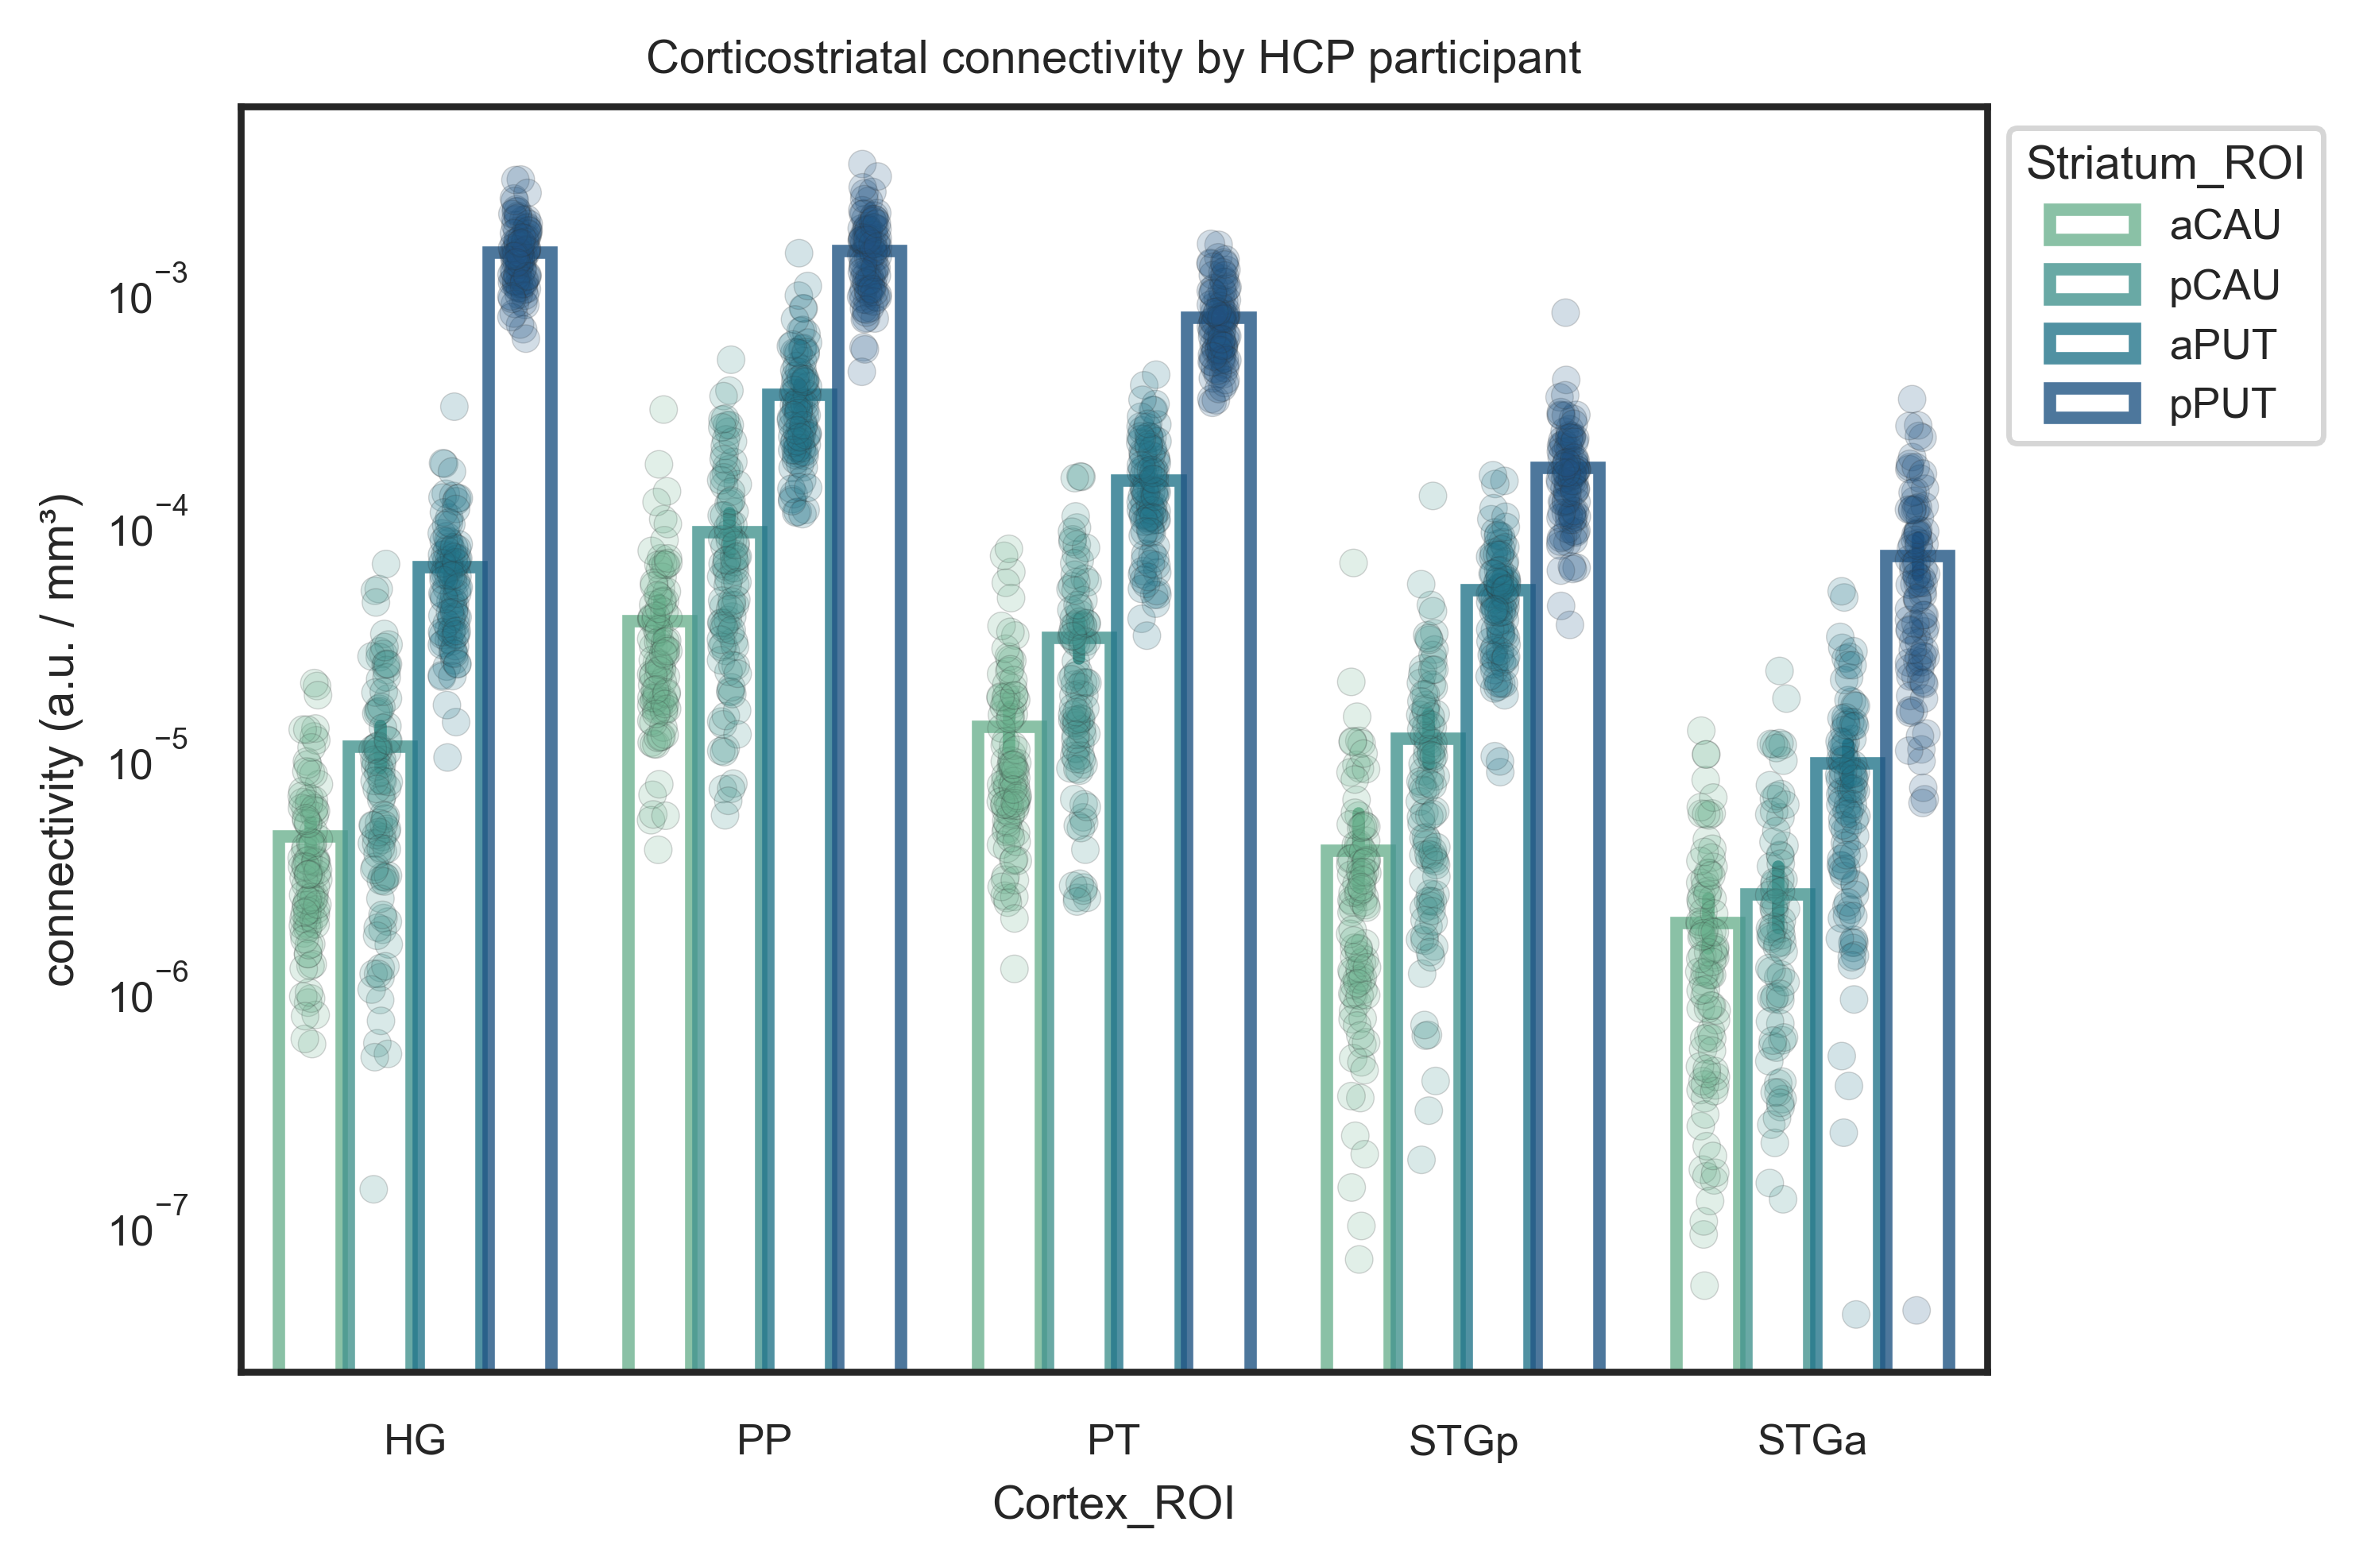

In [49]:
df_collapsed = aud_long_df.groupby(["participant_id", 'Cortex_ROI', 'Striatum_ROI',], 
                                       as_index=False).agg({"Connectivity": "mean"})

fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=500)

sns.barplot(data=df_collapsed, 
              x='Cortex_ROI', y='Connectivity', 
              order=auditory_rois,
              hue='Striatum_ROI', hue_order=['aCAU', 'pCAU', 'aPUT', 'pPUT'],
              palette='crest',  
              #fliersize=0, whis=(8, 92),
              #linewidth=1.5,
              alpha=0.8, gap=0.1, fill=False,
              #legend=None,
              ax=ax)
sns.stripplot(data=df_collapsed, 
              x='Cortex_ROI', y='Connectivity', 
              order=auditory_rois,
              hue='Striatum_ROI', hue_order=['aCAU', 'pCAU', 'aPUT', 'pPUT'],
              palette='crest',
              dodge=True,
              jitter=True,
              linewidth=0.2,
              alpha=0.2,
              legend=None,
              ax=ax)

#ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title(f'Corticostriatal connectivity by HCP participant');
plt.yscale('log')
ax.set_ylabel('connectivity (a.u. / mm³)')
#ax.set_ylim([-5, 5])

fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'streamline-count_x-cortex_hue-striatum.svg'))

## Across-participant statistics

**Omnibus ANOVAs** are repeated-measures ANOVAs on the untransformed connectivity
values: `statsmodels` `AnovaRM` for the 3- and 4-factor designs, and `pingouin`
`rm_anova` (Greenhouse–Geisser correction + partial η²) for the 2-factor designs.

**Pairwise post-hoc comparisons** use the **Wilcoxon signed-rank test**
(`pg.pairwise_tests(..., parametric=False)`, Benjamini–Hochberg FDR). The
connectivity values are strongly right-skewed with a spike at zero (region pairs
with no streamlines), which breaks the normality assumption of the paired
*t*-test; the rank-based Wilcoxon test is robust to it. The omnibus ANOVAs have
**not** yet been adapted (log-transform or non-parametric) — a known limitation.


In [50]:
from statsmodels.stats.anova import AnovaRM
import pingouin as pg

In [51]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))
from stats_fmt import export_anova, export_posthoc

STATS_OUT_DIR = 'stats_exports/no-gpexcl'
os.makedirs(STATS_OUT_DIR, exist_ok=True)

FIGURES_DIR = 'figures/no-gpexcl'
os.makedirs(FIGURES_DIR, exist_ok=True)


In [52]:
import numpy as np
import scipy.linalg

_orig_svd = np.linalg.svd
def _robust_svd(a, full_matrices=True, compute_uv=True, hermitian=False):
    try:
        return _orig_svd(a, full_matrices=full_matrices, compute_uv=compute_uv, hermitian=hermitian)
    except np.linalg.LinAlgError:
        print('  (SVD fallback: gesdd failed, retrying with gesvd)')
        return scipy.linalg.svd(a, full_matrices=full_matrices, lapack_driver='gesvd')
np.linalg.svd = _robust_svd


### All factors

In [53]:
# Mixed-Effects ANOVA with all factors and interactions
aov = AnovaRM(aud_long_df, 
              aggregate_func='mean',
              depvar='Connectivity', 
              subject='participant_id', 
              within=['Caudate_Putamen', 'Rostral_Caudal', 'Cortex_ROI', 'hemisphere',]).fit()

# Display results
aov.summary()
export_anova(aov, 'aud_full', STATS_OUT_DIR)


  (SVD fallback: gesdd failed, retrying with gesvd)


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Caudate_Putamen,1187.97,1.0,99.0,p < .001,,,,"F(1, 99) = 1187.97, p < .001"
1,Rostral_Caudal,965.74,1.0,99.0,p < .001,,,,"F(1, 99) = 965.74, p < .001"
2,Cortex_ROI,583.82,4.0,396.0,p < .001,,,,"F(4, 396) = 583.82, p < .001"
3,hemisphere,7.35,1.0,99.0,p = .008,,,,"F(1, 99) = 7.35, p = .008"
4,Caudate_Putamen:Rostral_Caudal,936.26,1.0,99.0,p < .001,,,,"F(1, 99) = 936.26, p < .001"
5,Caudate_Putamen:Cortex_ROI,519.40,4.0,396.0,p < .001,,,,"F(4, 396) = 519.40, p < .001"
6,Rostral_Caudal:Cortex_ROI,370.97,4.0,396.0,p < .001,,,,"F(4, 396) = 370.97, p < .001"
7,Caudate_Putamen:hemisphere,5.28,1.0,99.0,p = .024,,,,"F(1, 99) = 5.28, p = .024"
8,Rostral_Caudal:hemisphere,3.88,1.0,99.0,p = .052,,,,"F(1, 99) = 3.88, p = .052"
9,Cortex_ROI:hemisphere,52.66,4.0,396.0,p < .001,,,,"F(4, 396) = 52.66, p < .001"


### No hemisphere

In [54]:
# Mixed-Effects ANOVA with all factors and interactions
aov = AnovaRM(aud_long_df, 
              aggregate_func='mean',
              depvar='Connectivity', 
              subject='participant_id', 
              within=['Caudate_Putamen', 'Rostral_Caudal', 'Cortex_ROI']).fit()

# Display results
aov.summary()
export_anova(aov, 'aud_cau_rostral_roi', STATS_OUT_DIR)


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Caudate_Putamen,1187.97,1.0,99.0,p < .001,,,,"F(1, 99) = 1187.97, p < .001"
1,Rostral_Caudal,965.74,1.0,99.0,p < .001,,,,"F(1, 99) = 965.74, p < .001"
2,Cortex_ROI,583.82,4.0,396.0,p < .001,,,,"F(4, 396) = 583.82, p < .001"
3,Caudate_Putamen:Rostral_Caudal,936.26,1.0,99.0,p < .001,,,,"F(1, 99) = 936.26, p < .001"
4,Caudate_Putamen:Cortex_ROI,519.40,4.0,396.0,p < .001,,,,"F(4, 396) = 519.40, p < .001"
5,Rostral_Caudal:Cortex_ROI,370.97,4.0,396.0,p < .001,,,,"F(4, 396) = 370.97, p < .001"
6,Caudate_Putamen:Rostral_Caudal:Cortex_ROI,371.59,4.0,396.0,p < .001,,,,"F(4, 396) = 371.59, p < .001"


### Caudate–Putamen

In [55]:
# Mixed-Effects ANOVA with Hemisphere, Region, and Interaction
aov = AnovaRM(aud_long_df, 
              aggregate_func='mean',
              depvar='Connectivity', 
              subject='participant_id', 
              within=['Caudate_Putamen', 'Cortex_ROI', 'hemisphere',]).fit()

# Display results
aov.summary()
export_anova(aov, 'aud_cau_roi_hemi', STATS_OUT_DIR)


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Caudate_Putamen,1187.97,1.0,99.0,p < .001,,,,"F(1, 99) = 1187.97, p < .001"
1,Cortex_ROI,583.82,4.0,396.0,p < .001,,,,"F(4, 396) = 583.82, p < .001"
2,hemisphere,7.35,1.0,99.0,p = .008,,,,"F(1, 99) = 7.35, p = .008"
3,Caudate_Putamen:Cortex_ROI,519.40,4.0,396.0,p < .001,,,,"F(4, 396) = 519.40, p < .001"
4,Caudate_Putamen:hemisphere,5.28,1.0,99.0,p = .024,,,,"F(1, 99) = 5.28, p = .024"
5,Cortex_ROI:hemisphere,52.66,4.0,396.0,p < .001,,,,"F(4, 396) = 52.66, p < .001"
6,Caudate_Putamen:Cortex_ROI:hemisphere,67.76,4.0,396.0,p < .001,,,,"F(4, 396) = 67.76, p < .001"


#### 2-way: Cortex ROI x Caudate/Putamen

In [56]:
# 2-way RM-ANOVA (Greenhouse-Geisser + partial eta^2): the omnibus that the
# pairwise comparisons below follow up. Average over the other factors so
# there is one value per subject x cell.
_d = aud_long_df.groupby(['participant_id', 'Cortex_ROI', 'Caudate_Putamen'],
                     as_index=False)['Connectivity'].mean()
aov = pg.rm_anova(data=_d, dv='Connectivity',
                  within=['Cortex_ROI', 'Caudate_Putamen'],
                  subject='participant_id', detailed=True, effsize='np2')
display(aov)
export_anova(aov, 'aud_roi_cau', STATS_OUT_DIR)


,Source,SS,ddof1,ddof2,MS,F,p_unc,p_GG_corr,np2,eps
0,Cortex_ROI,0.000032,4,396,0.000008,583.815719,1.495784e-164,6.916389e-97,0.855012,0.581226
1,Caudate_Putamen,0.000047,1,99,0.000047,1187.966044,6.031439e-57,6.031439e-57,0.923075,1.000000
2,Cortex_ROI * Caudate_Putamen,0.000027,4,396,0.000007,519.404691,4.866996e-156,8.202771e-92,0.839911,0.580422


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Cortex_ROI,583.82,4,396,p < .001,p < .001,0.855,0.581,"F(2.32, 230.17) = 583.82, p < .001 (GG ε=0.58)..."
1,Caudate_Putamen,1187.97,1,99,p < .001,p < .001,0.923,1.000,"F(1, 99) = 1187.97, p < .001, ηp² = .92"
2,Cortex_ROI * Caudate_Putamen,519.40,4,396,p < .001,p < .001,0.840,0.580,"F(2.32, 229.85) = 519.40, p < .001 (GG ε=0.58)..."


In [57]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=aud_long_df,
                             dv='Connectivity', 
                             within=[ 'Caudate_Putamen', 'Cortex_ROI'],
                             subject='participant_id',
                             padjust='fdr', parametric=False) 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'Caudate_Putamen', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
#print(pairwise_interaction)
export_posthoc(pairwise, 'aud_cau_roi', STATS_OUT_DIR)


Available columns: Index(['Contrast', 'Caudate_Putamen', 'A', 'B', 'Paired', 'Parametric',
       'W_val', 'alternative', 'p_unc', 'p_corr', 'p_adjust', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Caudate_Putamen,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Caudate_Putamen,-,Caudate,Putamen,0.0,p < .001,n/a,"W = 0.0, p < .001",W = 0.0
1,Cortex_ROI,-,HG,PP,599.0,p < .001,p < .001,"W = 599.0, p < .001","W = 599.0, q < .001"
2,Cortex_ROI,-,HG,PT,44.0,p < .001,p < .001,"W = 44.0, p < .001","W = 44.0, q < .001"
3,Cortex_ROI,-,HG,STGa,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
4,Cortex_ROI,-,HG,STGp,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
5,Cortex_ROI,-,PP,PT,5.0,p < .001,p < .001,"W = 5.0, p < .001","W = 5.0, q < .001"
6,Cortex_ROI,-,PP,STGa,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
7,Cortex_ROI,-,PP,STGp,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
8,Cortex_ROI,-,PT,STGa,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
9,Cortex_ROI,-,PT,STGp,4.0,p < .001,p < .001,"W = 4.0, p < .001","W = 4.0, q < .001"


In [58]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=aud_long_df,
                             dv='Connectivity', 
                             within=['Cortex_ROI', 'Caudate_Putamen', ],
                             subject='participant_id',
                             padjust='fdr', parametric=False) 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'Cortex_ROI', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
#print(pairwise_interaction)
export_posthoc(pairwise, 'aud_roi_cau', STATS_OUT_DIR)


Available columns: Index(['Contrast', 'Cortex_ROI', 'A', 'B', 'Paired', 'Parametric', 'W_val',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Cortex_ROI,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Cortex_ROI,-,HG,PP,599.0,p < .001,p < .001,"W = 599.0, p < .001","W = 599.0, q < .001"
1,Cortex_ROI,-,HG,PT,44.0,p < .001,p < .001,"W = 44.0, p < .001","W = 44.0, q < .001"
2,Cortex_ROI,-,HG,STGa,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
3,Cortex_ROI,-,HG,STGp,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
4,Cortex_ROI,-,PP,PT,5.0,p < .001,p < .001,"W = 5.0, p < .001","W = 5.0, q < .001"
5,Cortex_ROI,-,PP,STGa,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
6,Cortex_ROI,-,PP,STGp,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
7,Cortex_ROI,-,PT,STGa,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
8,Cortex_ROI,-,PT,STGp,4.0,p < .001,p < .001,"W = 4.0, p < .001","W = 4.0, q < .001"
9,Cortex_ROI,-,STGa,STGp,18.0,p < .001,p < .001,"W = 18.0, p < .001","W = 18.0, q < .001"


In [59]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=aud_long_df,
                             dv='Connectivity', 
                             within=[ 'hemisphere', 'Cortex_ROI',],
                             subject='participant_id',
                             padjust='fdr', parametric=False) 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'hemisphere', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
#print(pairwise_interaction)
export_posthoc(pairwise, 'aud_hemi_roi', STATS_OUT_DIR)


Available columns: Index(['Contrast', 'hemisphere', 'A', 'B', 'Paired', 'Parametric', 'W_val',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,hemisphere,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,hemisphere,-,Left,Right,1785.0,p = .011,n/a,"W = 1785.0, p = .011",W = 1785.0
1,Cortex_ROI,-,HG,PP,599.0,p < .001,p < .001,"W = 599.0, p < .001","W = 599.0, q < .001"
2,Cortex_ROI,-,HG,PT,44.0,p < .001,p < .001,"W = 44.0, p < .001","W = 44.0, q < .001"
3,Cortex_ROI,-,HG,STGa,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
4,Cortex_ROI,-,HG,STGp,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
5,Cortex_ROI,-,PP,PT,5.0,p < .001,p < .001,"W = 5.0, p < .001","W = 5.0, q < .001"
6,Cortex_ROI,-,PP,STGa,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
7,Cortex_ROI,-,PP,STGp,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
8,Cortex_ROI,-,PT,STGa,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
9,Cortex_ROI,-,PT,STGp,4.0,p < .001,p < .001,"W = 4.0, p < .001","W = 4.0, q < .001"


In [60]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=aud_long_df,
                             dv='Connectivity', 
                             within=[ 'Cortex_ROI', 'hemisphere',],
                             subject='participant_id',
                             padjust='fdr', parametric=False) 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'Cortex_ROI', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
#print(pairwise_interaction)
export_posthoc(pairwise, 'aud_roi_hemi', STATS_OUT_DIR)


Available columns: Index(['Contrast', 'Cortex_ROI', 'A', 'B', 'Paired', 'Parametric', 'W_val',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Cortex_ROI,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Cortex_ROI,-,HG,PP,599.0,p < .001,p < .001,"W = 599.0, p < .001","W = 599.0, q < .001"
1,Cortex_ROI,-,HG,PT,44.0,p < .001,p < .001,"W = 44.0, p < .001","W = 44.0, q < .001"
2,Cortex_ROI,-,HG,STGa,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
3,Cortex_ROI,-,HG,STGp,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
4,Cortex_ROI,-,PP,PT,5.0,p < .001,p < .001,"W = 5.0, p < .001","W = 5.0, q < .001"
5,Cortex_ROI,-,PP,STGa,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
6,Cortex_ROI,-,PP,STGp,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
7,Cortex_ROI,-,PT,STGa,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
8,Cortex_ROI,-,PT,STGp,4.0,p < .001,p < .001,"W = 4.0, p < .001","W = 4.0, q < .001"
9,Cortex_ROI,-,STGa,STGp,18.0,p < .001,p < .001,"W = 18.0, p < .001","W = 18.0, q < .001"


In [61]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=aud_long_df,
                             dv='Connectivity', 
                             within=['Striatum_ROI', 'hemisphere', ],
                             subject='participant_id',
                             padjust='fdr', parametric=False) 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast', 'Striatum_ROI', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
#print(pairwise)
export_posthoc(pairwise, 'aud_striatum_hemi', STATS_OUT_DIR)


Available columns: Index(['Contrast', 'Striatum_ROI', 'A', 'B', 'Paired', 'Parametric', 'W_val',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Striatum_ROI,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Striatum_ROI,-,aCAU,aPUT,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
1,Striatum_ROI,-,aCAU,pCAU,246.0,p < .001,p < .001,"W = 246.0, p < .001","W = 246.0, q < .001"
2,Striatum_ROI,-,aCAU,pPUT,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
3,Striatum_ROI,-,aPUT,pCAU,32.0,p < .001,p < .001,"W = 32.0, p < .001","W = 32.0, q < .001"
4,Striatum_ROI,-,aPUT,pPUT,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
5,Striatum_ROI,-,pCAU,pPUT,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
6,hemisphere,-,Left,Right,1785.0,p = .011,n/a,"W = 1785.0, p = .011",W = 1785.0
7,Striatum_ROI * hemisphere,aCAU,Left,Right,2040.0,p = .096,p = .128,"W = 2040.0, p = .096","W = 2040.0, q = .128"
8,Striatum_ROI * hemisphere,aPUT,Left,Right,346.0,p < .001,p < .001,"W = 346.0, p < .001","W = 346.0, q < .001"
9,Striatum_ROI * hemisphere,pCAU,Left,Right,1807.0,p = .014,p = .027,"W = 1807.0, p = .014","W = 1807.0, q = .027"


### Rostral–caudal

In [62]:
# Mixed-Effects ANOVA with Hemisphere, Region, and Interaction
aov = AnovaRM(aud_long_df, 
              aggregate_func='mean',
              depvar='Connectivity', 
              subject='participant_id', 
              within=['Rostral_Caudal', 'hemisphere', 'Cortex_ROI']).fit()

# Display results
aov.summary()
export_anova(aov, 'aud_rostral_hemi_roi', STATS_OUT_DIR)


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Rostral_Caudal,965.74,1.0,99.0,p < .001,,,,"F(1, 99) = 965.74, p < .001"
1,hemisphere,7.35,1.0,99.0,p = .008,,,,"F(1, 99) = 7.35, p = .008"
2,Cortex_ROI,583.82,4.0,396.0,p < .001,,,,"F(4, 396) = 583.82, p < .001"
3,Rostral_Caudal:hemisphere,3.88,1.0,99.0,p = .052,,,,"F(1, 99) = 3.88, p = .052"
4,Rostral_Caudal:Cortex_ROI,370.97,4.0,396.0,p < .001,,,,"F(4, 396) = 370.97, p < .001"
5,hemisphere:Cortex_ROI,52.66,4.0,396.0,p < .001,,,,"F(4, 396) = 52.66, p < .001"
6,Rostral_Caudal:hemisphere:Cortex_ROI,56.21,4.0,396.0,p < .001,,,,"F(4, 396) = 56.21, p < .001"


#### 2-way: Cortex ROI x Rostral/Caudal

In [63]:
# 2-way RM-ANOVA (Greenhouse-Geisser + partial eta^2): the omnibus that the
# pairwise comparisons below follow up. Average over the other factors so
# there is one value per subject x cell.
_d = aud_long_df.groupby(['participant_id', 'Cortex_ROI', 'Rostral_Caudal'],
                     as_index=False)['Connectivity'].mean()
aov = pg.rm_anova(data=_d, dv='Connectivity',
                  within=['Cortex_ROI', 'Rostral_Caudal'],
                  subject='participant_id', detailed=True, effsize='np2')
display(aov)
export_anova(aov, 'aud_roi_rostral', STATS_OUT_DIR)


,Source,SS,ddof1,ddof2,MS,F,p_unc,p_GG_corr,np2,eps
0,Cortex_ROI,0.000032,4,396,0.000008,583.815719,1.495784e-164,6.916389e-97,0.855012,0.581226
1,Rostral_Caudal,0.000028,1,99,0.000028,965.736906,7.231455e-53,7.231455e-53,0.907019,1.000000
2,Cortex_ROI * Rostral_Caudal,0.000018,4,396,0.000004,370.967541,1.832461e-132,1.524206e-72,0.789347,0.537415


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Cortex_ROI,583.82,4,396,p < .001,p < .001,0.855,0.581,"F(2.32, 230.17) = 583.82, p < .001 (GG ε=0.58)..."
1,Rostral_Caudal,965.74,1,99,p < .001,p < .001,0.907,1.000,"F(1, 99) = 965.74, p < .001, ηp² = .91"
2,Cortex_ROI * Rostral_Caudal,370.97,4,396,p < .001,p < .001,0.789,0.537,"F(2.15, 212.82) = 370.97, p < .001 (GG ε=0.54)..."


In [64]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=aud_long_df,
                             dv='Connectivity', 
                             within=[ 'hemisphere', 'Rostral_Caudal',],
                             subject='participant_id',
                             padjust='fdr', parametric=False) 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'hemisphere', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
#print(pairwise_interaction)
export_posthoc(pairwise, 'aud_hemi_rostral', STATS_OUT_DIR)


Available columns: Index(['Contrast', 'hemisphere', 'A', 'B', 'Paired', 'Parametric', 'W_val',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,hemisphere,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,hemisphere,-,Left,Right,1785.0,p = .011,n/a,"W = 1785.0, p = .011",W = 1785.0
1,Rostral_Caudal,-,Caudal,Rostral,0.0,p < .001,n/a,"W = 0.0, p < .001",W = 0.0
2,hemisphere * Rostral_Caudal,Left,Caudal,Rostral,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
3,hemisphere * Rostral_Caudal,Right,Caudal,Rostral,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"


In [65]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=aud_long_df,
                             dv='Connectivity', 
                             within=['Rostral_Caudal', 'hemisphere', ],
                             subject='participant_id',
                             padjust='fdr', parametric=False) 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast', 'Rostral_Caudal', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
#print(pairwise_interaction)
export_posthoc(pairwise, 'aud_rostral_hemi', STATS_OUT_DIR)


Available columns: Index(['Contrast', 'Rostral_Caudal', 'A', 'B', 'Paired', 'Parametric', 'W_val',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Rostral_Caudal,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Rostral_Caudal,-,Caudal,Rostral,0.0,p < .001,n/a,"W = 0.0, p < .001",W = 0.0
1,hemisphere,-,Left,Right,1785.0,p = .011,n/a,"W = 1785.0, p = .011",W = 1785.0
2,Rostral_Caudal * hemisphere,Caudal,Left,Right,2473.0,p = .859,p = .859,"W = 2473.0, p = .859","W = 2473.0, q = .859"
3,Rostral_Caudal * hemisphere,Rostral,Left,Right,376.0,p < .001,p < .001,"W = 376.0, p < .001","W = 376.0, q < .001"


In [66]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=aud_long_df,
                             dv='Connectivity', 
                             within=[ 'Cortex_ROI', 'Rostral_Caudal',],
                             subject='participant_id',
                             padjust='fdr', parametric=False) 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'Cortex_ROI', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
#print(pairwise_interaction)
export_posthoc(pairwise, 'aud_roi_rostral', STATS_OUT_DIR)


Available columns: Index(['Contrast', 'Cortex_ROI', 'A', 'B', 'Paired', 'Parametric', 'W_val',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Cortex_ROI,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Cortex_ROI,-,HG,PP,599.0,p < .001,p < .001,"W = 599.0, p < .001","W = 599.0, q < .001"
1,Cortex_ROI,-,HG,PT,44.0,p < .001,p < .001,"W = 44.0, p < .001","W = 44.0, q < .001"
2,Cortex_ROI,-,HG,STGa,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
3,Cortex_ROI,-,HG,STGp,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
4,Cortex_ROI,-,PP,PT,5.0,p < .001,p < .001,"W = 5.0, p < .001","W = 5.0, q < .001"
5,Cortex_ROI,-,PP,STGa,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
6,Cortex_ROI,-,PP,STGp,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
7,Cortex_ROI,-,PT,STGa,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
8,Cortex_ROI,-,PT,STGp,4.0,p < .001,p < .001,"W = 4.0, p < .001","W = 4.0, q < .001"
9,Cortex_ROI,-,STGa,STGp,18.0,p < .001,p < .001,"W = 18.0, p < .001","W = 18.0, q < .001"


### Auditory vs. Prefrontal

In [69]:
auditory_rois   = ['HG', 'PP', 'PT', 'STGa', 'STGp']
prefrontal_rois = PREFRONTAL_ROIS
                  #['FP', 'SFG', 'MFG', 'PreCG', 
                  # 'IFGt', 'IFGo',
                  # 'FMC', 'PCG', 'ACC', 'OFC', 'FO']

category_map = {r: 'Auditory'   for r in auditory_rois}
category_map.update({r: 'Prefrontal' for r in prefrontal_rois})

aud_pfc_df = all_long_df[all_long_df['Cortex_ROI'].isin(auditory_rois + prefrontal_rois)].copy()
aud_pfc_df['Cortex_Category'] = aud_pfc_df['Cortex_ROI'].map(category_map)

In [70]:
# 2-way RM-ANOVA via pingouin: Greenhouse-Geisser correction + partial eta^2.
# pingouin needs one value per subject x cell, so average over the other
# factors first (Cortex_ROI, hemisphere, Rostral_Caudal) -- this is what
# AnovaRM(aggregate_func='mean') did implicitly.
_d = aud_pfc_df.groupby(['participant_id', 'Cortex_Category', 'Caudate_Putamen'],
                        as_index=False)['Connectivity'].mean()
aov = pg.rm_anova(data=_d, dv='Connectivity',
                  within=['Cortex_Category', 'Caudate_Putamen'],
                  subject='participant_id', detailed=True, effsize='np2')
display(aov)
export_anova(aov, 'aud_pfc_category', STATS_OUT_DIR)


,Source,SS,ddof1,ddof2,MS,F,p_unc,p_GG_corr,np2,eps
0,Cortex_Category,0.000002,1,99,0.000002,103.242557,4.878115e-17,4.878115e-17,0.510489,1.0
1,Caudate_Putamen,0.000006,1,99,0.000006,404.014061,1.012269e-36,1.012269e-36,0.803186,1.0
2,Cortex_Category * Caudate_Putamen,0.000003,1,99,0.000003,309.677724,3.037256e-32,3.037256e-32,0.757755,1.0


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Cortex_Category,103.24,1,99,p < .001,p < .001,0.510,1.000,"F(1, 99) = 103.24, p < .001, ηp² = .51"
1,Caudate_Putamen,404.01,1,99,p < .001,p < .001,0.803,1.000,"F(1, 99) = 404.01, p < .001, ηp² = .80"
2,Cortex_Category * Caudate_Putamen,309.68,1,99,p < .001,p < .001,0.758,1.000,"F(1, 99) = 309.68, p < .001, ηp² = .76"


In [71]:
pairwise = pg.pairwise_tests(data=aud_pfc_df,
                             dv='Connectivity',
                             within=['Cortex_Category', 'Caudate_Putamen'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)
pairwise[['Contrast', 'Cortex_Category', 'A', 'B', 'W_val', 'p_unc', 'hedges']]
export_posthoc(pairwise, 'aud_pfc_category_cau', STATS_OUT_DIR)


,Contrast,Cortex_Category,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Cortex_Category,-,Auditory,Prefrontal,189.0,p < .001,n/a,"W = 189.0, p < .001",W = 189.0
1,Caudate_Putamen,-,Caudate,Putamen,18.0,p < .001,n/a,"W = 18.0, p < .001",W = 18.0
2,Cortex_Category * Caudate_Putamen,Auditory,Caudate,Putamen,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
3,Cortex_Category * Caudate_Putamen,Prefrontal,Caudate,Putamen,1399.0,p < .001,p < .001,"W = 1399.0, p < .001","W = 1399.0, q < .001"


In [72]:
pairwise = pg.pairwise_tests(data=aud_pfc_df,
                             dv='Connectivity',
                             within=['Caudate_Putamen', 'Cortex_Category'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)
pairwise[['Contrast', 'Caudate_Putamen', 'A', 'B', 'W_val', 'p_unc', 'hedges']]
export_posthoc(pairwise, 'aud_pfc_cau_category', STATS_OUT_DIR)


,Contrast,Caudate_Putamen,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Caudate_Putamen,-,Caudate,Putamen,18.0,p < .001,n/a,"W = 18.0, p < .001",W = 18.0
1,Cortex_Category,-,Auditory,Prefrontal,189.0,p < .001,n/a,"W = 189.0, p < .001",W = 189.0
2,Caudate_Putamen * Cortex_Category,Caudate,Auditory,Prefrontal,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
3,Caudate_Putamen * Cortex_Category,Putamen,Auditory,Prefrontal,1444.0,p < .001,p < .001,"W = 1444.0, p < .001","W = 1444.0, q < .001"


/var/folders/5c/_fg_mvnx2dv1jhkw5xg5fv1h0000gq/T/ipykernel_96211/607020177.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([_display_label(r) for r in PREFRONTAL_ROIS])


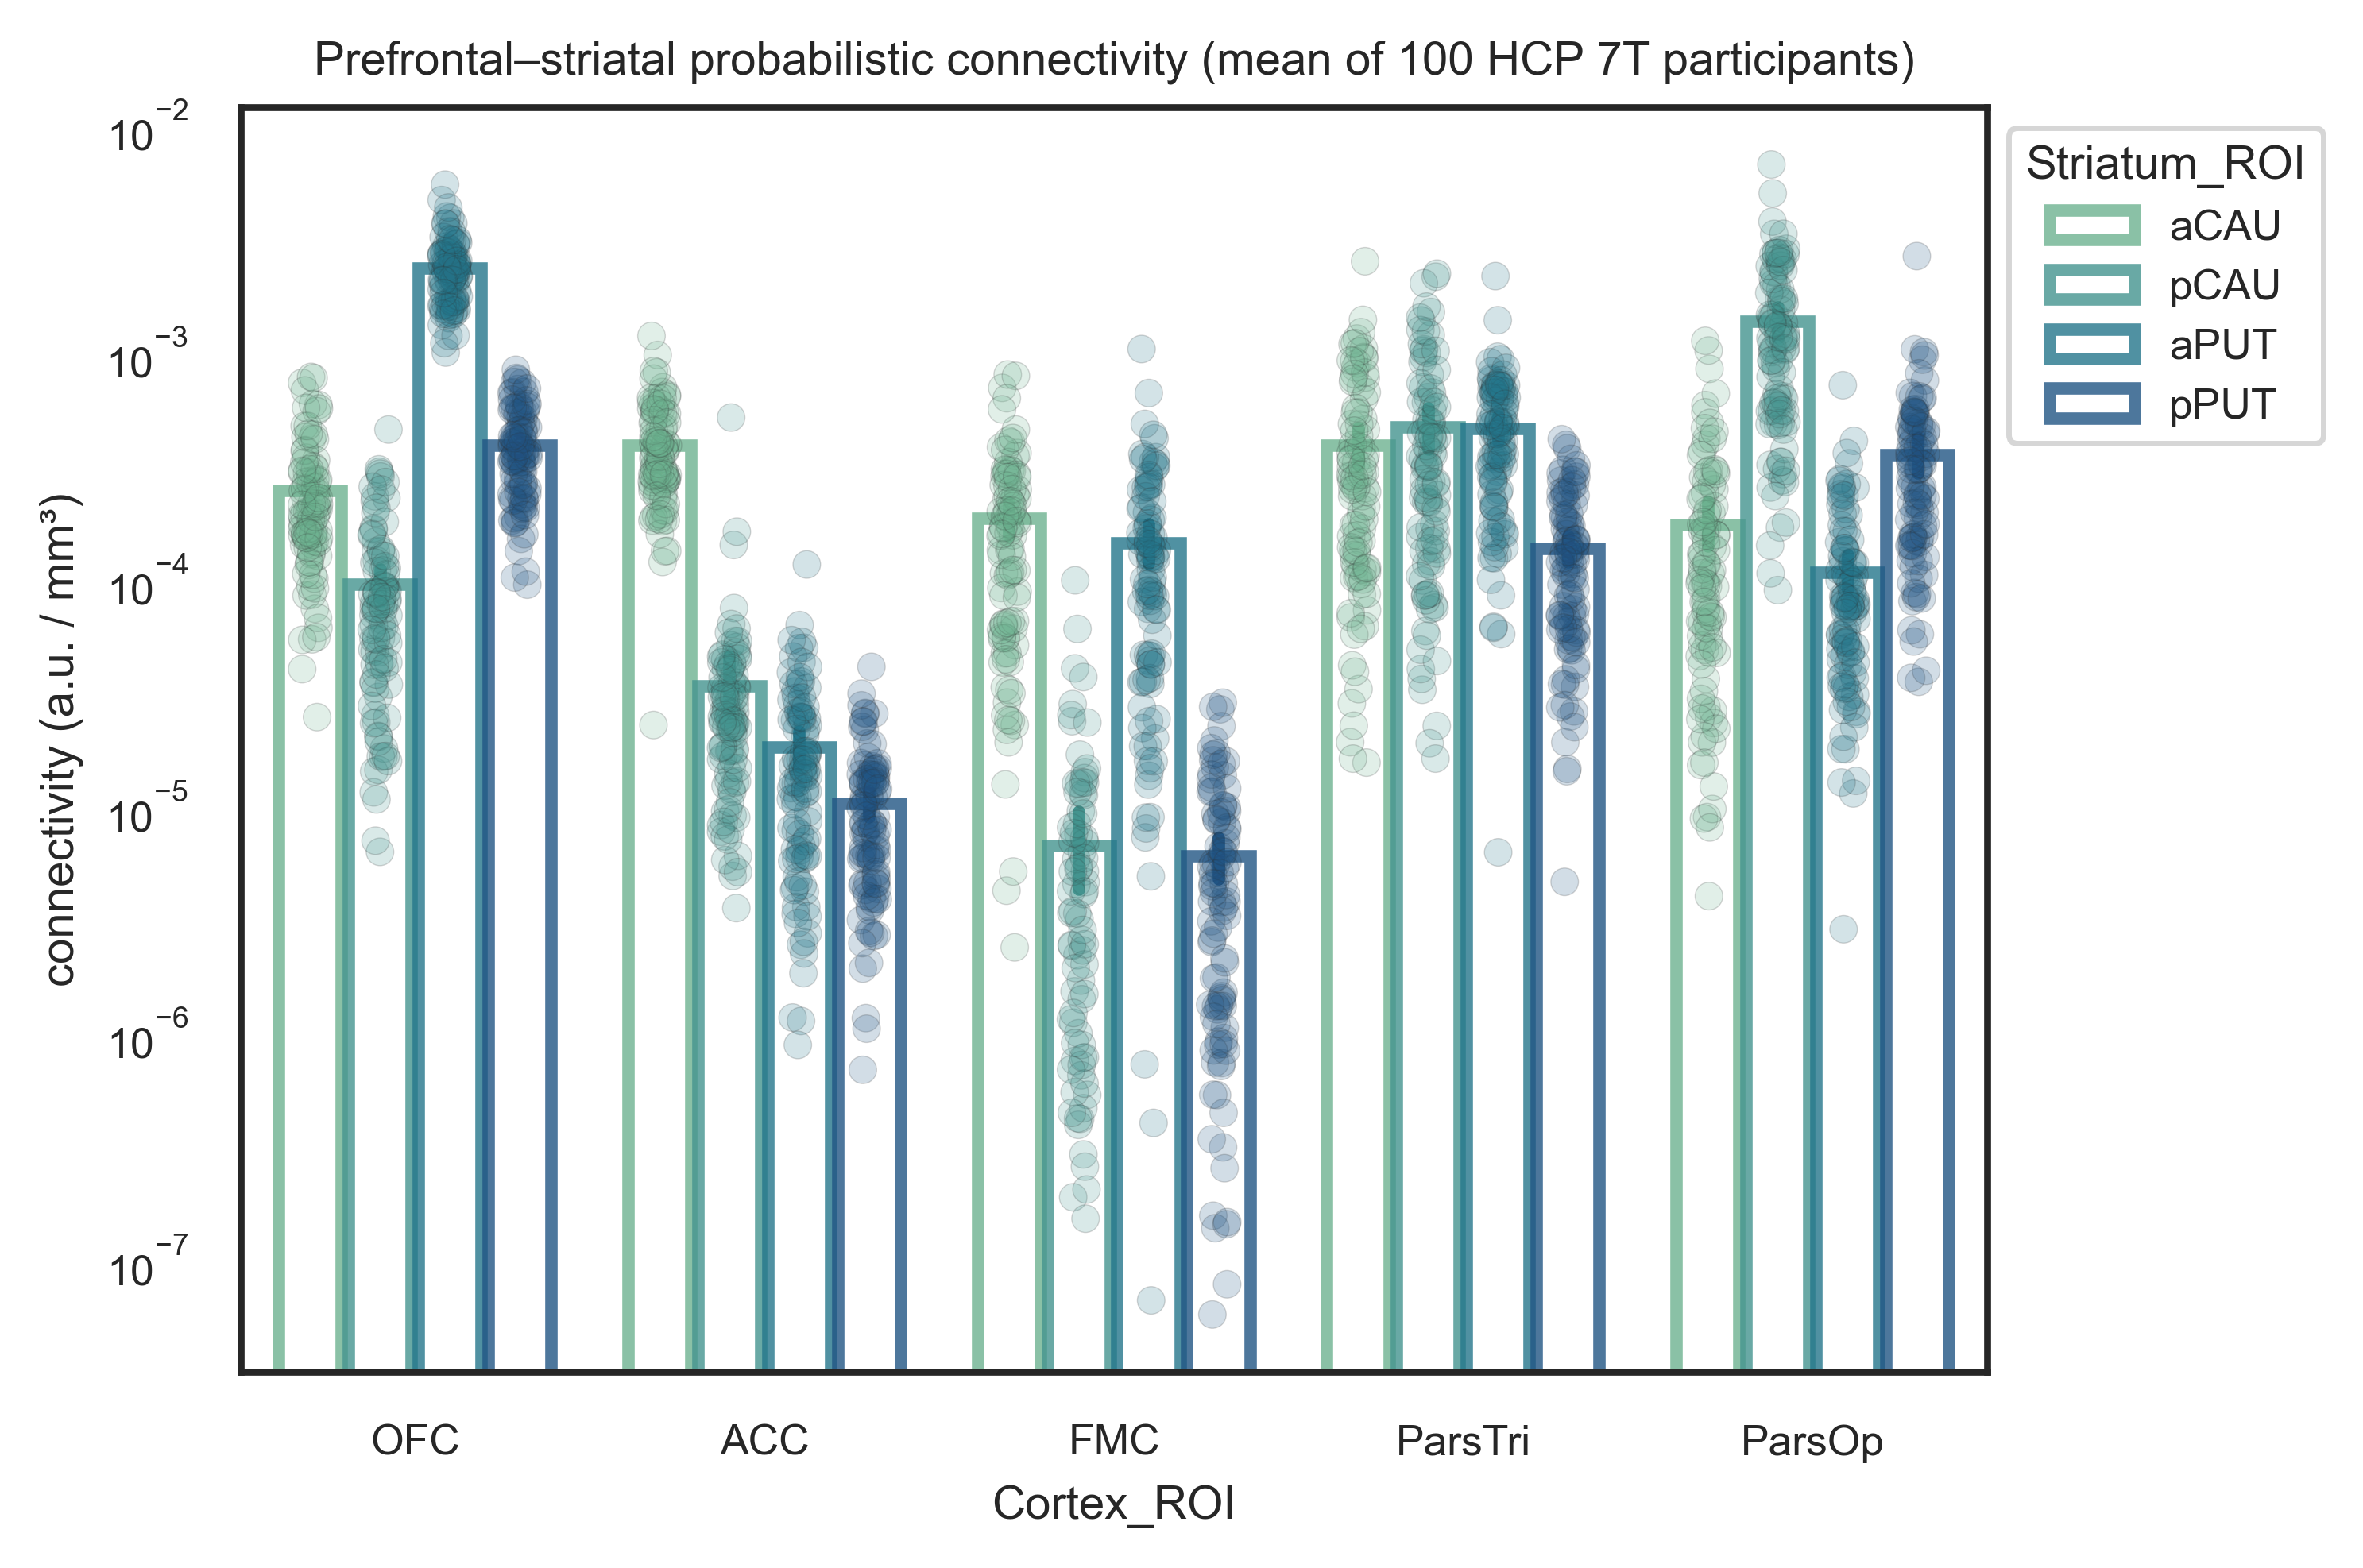

In [73]:
pfc_df = aud_pfc_df[aud_pfc_df['Cortex_Category'] == 'Prefrontal']
pfc_df = pfc_df[pfc_df['Cortex_ROI'].isin(PREFRONTAL_ROIS)]

df_collapsed_pfc = pfc_df.groupby(['participant_id', 'Cortex_ROI', 'Striatum_ROI'],
                                   as_index=False).agg({'Connectivity': 'mean'})

fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=500)

sns.barplot(data=df_collapsed_pfc,
            x='Cortex_ROI', y='Connectivity',
            order=PREFRONTAL_ROIS,
            hue='Striatum_ROI', hue_order=['aCAU', 'pCAU', 'aPUT', 'pPUT'],
            palette='crest',
            alpha=0.8, gap=0.1, fill=False,
            ax=ax)
sns.stripplot(data=df_collapsed_pfc,
              x='Cortex_ROI', y='Connectivity',
              order=PREFRONTAL_ROIS,
              hue='Striatum_ROI', hue_order=['aCAU', 'pCAU', 'aPUT', 'pPUT'],
              palette='crest',
              dodge=True, jitter=True,
              linewidth=0.2, alpha=0.2,
              legend=None,
              ax=ax)

ax.set_xticklabels([_display_label(r) for r in PREFRONTAL_ROIS])
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1))
ax.set_title(f'Prefrontal–striatal probabilistic connectivity (mean of {num_participants} HCP 7T participants)')
plt.yscale('log')
ax.set_ylabel('connectivity (a.u. / mm³)')

fig.savefig(os.path.join(FIGURES_DIR, 'streamline-count_x-prefrontal_hue-striatum.svg'))
fig.tight_layout()


### PFC statistics

In [74]:
pfc_long_df = all_long_df[all_long_df['Cortex_ROI'].isin(PREFRONTAL_ROIS)]


#### All factors

In [75]:
aov = AnovaRM(pfc_long_df,
              aggregate_func='mean',
              depvar='Connectivity',
              subject='participant_id',
              within=['Caudate_Putamen', 'Rostral_Caudal', 'Cortex_ROI', 'hemisphere']).fit()
aov.summary()
export_anova(aov, 'pfc_full', STATS_OUT_DIR)


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Caudate_Putamen,11.39,1.0,99.0,p = .001,,,,"F(1, 99) = 11.39, p = .001"
1,Rostral_Caudal,138.68,1.0,99.0,p < .001,,,,"F(1, 99) = 138.68, p < .001"
2,Cortex_ROI,200.23,4.0,396.0,p < .001,,,,"F(4, 396) = 200.23, p < .001"
3,hemisphere,174.71,1.0,99.0,p < .001,,,,"F(1, 99) = 174.71, p < .001"
4,Caudate_Putamen:Rostral_Caudal,349.60,1.0,99.0,p < .001,,,,"F(1, 99) = 349.60, p < .001"
5,Caudate_Putamen:Cortex_ROI,426.23,4.0,396.0,p < .001,,,,"F(4, 396) = 426.23, p < .001"
6,Rostral_Caudal:Cortex_ROI,377.27,4.0,396.0,p < .001,,,,"F(4, 396) = 377.27, p < .001"
7,Caudate_Putamen:hemisphere,86.79,1.0,99.0,p < .001,,,,"F(1, 99) = 86.79, p < .001"
8,Rostral_Caudal:hemisphere,106.84,1.0,99.0,p < .001,,,,"F(1, 99) = 106.84, p < .001"
9,Cortex_ROI:hemisphere,83.21,4.0,396.0,p < .001,,,,"F(4, 396) = 83.21, p < .001"


#### No hemisphere

In [76]:
aov = AnovaRM(pfc_long_df,
              aggregate_func='mean',
              depvar='Connectivity',
              subject='participant_id',
              within=['Caudate_Putamen', 'Rostral_Caudal', 'Cortex_ROI']).fit()
aov.summary()
export_anova(aov, 'pfc_cau_rostral_roi', STATS_OUT_DIR)


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Caudate_Putamen,11.39,1.0,99.0,p = .001,,,,"F(1, 99) = 11.39, p = .001"
1,Rostral_Caudal,138.68,1.0,99.0,p < .001,,,,"F(1, 99) = 138.68, p < .001"
2,Cortex_ROI,200.23,4.0,396.0,p < .001,,,,"F(4, 396) = 200.23, p < .001"
3,Caudate_Putamen:Rostral_Caudal,349.60,1.0,99.0,p < .001,,,,"F(1, 99) = 349.60, p < .001"
4,Caudate_Putamen:Cortex_ROI,426.23,4.0,396.0,p < .001,,,,"F(4, 396) = 426.23, p < .001"
5,Rostral_Caudal:Cortex_ROI,377.27,4.0,396.0,p < .001,,,,"F(4, 396) = 377.27, p < .001"
6,Caudate_Putamen:Rostral_Caudal:Cortex_ROI,233.15,4.0,396.0,p < .001,,,,"F(4, 396) = 233.15, p < .001"


#### Caudate–Putamen

##### 2-way: Cortex ROI x Caudate/Putamen

In [77]:
# 2-way RM-ANOVA (Greenhouse-Geisser + partial eta^2): the omnibus that the
# pairwise comparisons below follow up. Average over the other factors so
# there is one value per subject x cell.
_d = pfc_long_df.groupby(['participant_id', 'Cortex_ROI', 'Caudate_Putamen'],
                     as_index=False)['Connectivity'].mean()
aov = pg.rm_anova(data=_d, dv='Connectivity',
                  within=['Cortex_ROI', 'Caudate_Putamen'],
                  subject='participant_id', detailed=True, effsize='np2')
display(aov)
export_anova(aov, 'pfc_roi_cau', STATS_OUT_DIR)


,Source,SS,ddof1,ddof2,MS,F,p_unc,p_GG_corr,np2,eps
0,Cortex_ROI,0.000067,4,396,0.000017,200.228607,1.029452e-93,4.777478e-55,0.669149,0.574383
1,Caudate_Putamen,0.000001,1,99,0.000001,11.394249,1.053530e-03,1.053530e-03,0.103214,1.000000
2,Cortex_ROI * Caudate_Putamen,0.000091,4,396,0.000023,426.230387,5.189836e-142,9.618432e-80,0.811511,0.552243


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Cortex_ROI,200.23,4,396,p < .001,p < .001,0.669,0.574,"F(2.30, 227.46) = 200.23, p < .001 (GG ε=0.57)..."
1,Caudate_Putamen,11.39,1,99,p = .001,p = .001,0.103,1.000,"F(1, 99) = 11.39, p = .001, ηp² = .10"
2,Cortex_ROI * Caudate_Putamen,426.23,4,396,p < .001,p < .001,0.812,0.552,"F(2.21, 218.69) = 426.23, p < .001 (GG ε=0.55)..."


In [78]:
# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=pfc_long_df,
                             dv='Connectivity',
                             within=['Caudate_Putamen', 'Cortex_ROI'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)

print('Available columns:', pairwise.columns)
print('\nPost-hoc Pairwise Comparisons:')
pd.set_option('display.max_rows', None)

pairwise[['Contrast', 'Caudate_Putamen', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
export_df = pairwise.copy()
for col in ('A', 'B', 'Cortex_ROI'):
    if col in export_df.columns:
        export_df[col] = export_df[col].replace(ROI_DISPLAY_NAMES)
export_posthoc(export_df, 'pfc_cau_roi', STATS_OUT_DIR)


Available columns: Index(['Contrast', 'Caudate_Putamen', 'A', 'B', 'Paired', 'Parametric',
       'W_val', 'alternative', 'p_unc', 'p_corr', 'p_adjust', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Caudate_Putamen,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Caudate_Putamen,-,Caudate,Putamen,1399.0,p < .001,n/a,"W = 1399.0, p < .001",W = 1399.0
1,Cortex_ROI,-,ACC,FMC,1124.0,p < .001,p < .001,"W = 1124.0, p < .001","W = 1124.0, q < .001"
2,Cortex_ROI,-,ACC,ParsOp,36.0,p < .001,p < .001,"W = 36.0, p < .001","W = 36.0, q < .001"
3,Cortex_ROI,-,ACC,ParsTri,229.0,p < .001,p < .001,"W = 229.0, p < .001","W = 229.0, q < .001"
4,Cortex_ROI,-,ACC,OFC,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
5,Cortex_ROI,-,FMC,ParsOp,32.0,p < .001,p < .001,"W = 32.0, p < .001","W = 32.0, q < .001"
6,Cortex_ROI,-,FMC,ParsTri,133.0,p < .001,p < .001,"W = 133.0, p < .001","W = 133.0, q < .001"
7,Cortex_ROI,-,FMC,OFC,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
8,Cortex_ROI,-,ParsOp,ParsTri,905.0,p < .001,p < .001,"W = 905.0, p < .001","W = 905.0, q < .001"
9,Cortex_ROI,-,ParsOp,OFC,648.0,p < .001,p < .001,"W = 648.0, p < .001","W = 648.0, q < .001"


In [79]:
# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=pfc_long_df,
                             dv='Connectivity',
                             within=['Cortex_ROI', 'Caudate_Putamen'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)

print('Available columns:', pairwise.columns)
print('\nPost-hoc Pairwise Comparisons:')
pd.set_option('display.max_rows', None)

pairwise[['Contrast', 'Cortex_ROI', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
export_df = pairwise.copy()
for col in ('A', 'B', 'Cortex_ROI'):
    if col in export_df.columns:
        export_df[col] = export_df[col].replace(ROI_DISPLAY_NAMES)
export_posthoc(export_df, 'pfc_roi_cau', STATS_OUT_DIR)


Available columns: Index(['Contrast', 'Cortex_ROI', 'A', 'B', 'Paired', 'Parametric', 'W_val',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Cortex_ROI,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Cortex_ROI,-,ACC,FMC,1124.0,p < .001,p < .001,"W = 1124.0, p < .001","W = 1124.0, q < .001"
1,Cortex_ROI,-,ACC,ParsOp,36.0,p < .001,p < .001,"W = 36.0, p < .001","W = 36.0, q < .001"
2,Cortex_ROI,-,ACC,ParsTri,229.0,p < .001,p < .001,"W = 229.0, p < .001","W = 229.0, q < .001"
3,Cortex_ROI,-,ACC,OFC,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
4,Cortex_ROI,-,FMC,ParsOp,32.0,p < .001,p < .001,"W = 32.0, p < .001","W = 32.0, q < .001"
5,Cortex_ROI,-,FMC,ParsTri,133.0,p < .001,p < .001,"W = 133.0, p < .001","W = 133.0, q < .001"
6,Cortex_ROI,-,FMC,OFC,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
7,Cortex_ROI,-,ParsOp,ParsTri,905.0,p < .001,p < .001,"W = 905.0, p < .001","W = 905.0, q < .001"
8,Cortex_ROI,-,ParsOp,OFC,648.0,p < .001,p < .001,"W = 648.0, p < .001","W = 648.0, q < .001"
9,Cortex_ROI,-,ParsTri,OFC,200.0,p < .001,p < .001,"W = 200.0, p < .001","W = 200.0, q < .001"


#### Rostral–caudal

##### 2-way: Cortex ROI x Rostral/Caudal

In [80]:
# 2-way RM-ANOVA (Greenhouse-Geisser + partial eta^2): the omnibus that the
# pairwise comparisons below follow up. Average over the other factors so
# there is one value per subject x cell.
_d = pfc_long_df.groupby(['participant_id', 'Cortex_ROI', 'Rostral_Caudal'],
                     as_index=False)['Connectivity'].mean()
aov = pg.rm_anova(data=_d, dv='Connectivity',
                  within=['Cortex_ROI', 'Rostral_Caudal'],
                  subject='participant_id', detailed=True, effsize='np2')
display(aov)
export_anova(aov, 'pfc_roi_rostral', STATS_OUT_DIR)


,Source,SS,ddof1,ddof2,MS,F,p_unc,p_GG_corr,np2,eps
0,Cortex_ROI,0.000067,4,396,0.000017,200.228607,1.029452e-93,4.777478e-55,0.669149,0.574383
1,Rostral_Caudal,0.000007,1,99,0.000007,138.684546,1.544861e-20,1.544861e-20,0.583482,1.000000
2,Cortex_ROI * Rostral_Caudal,0.000082,4,396,0.000020,377.269942,1.315420e-133,1.894244e-65,0.792135,0.478461


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Cortex_ROI,200.23,4,396,p < .001,p < .001,0.669,0.574,"F(2.30, 227.46) = 200.23, p < .001 (GG ε=0.57)..."
1,Rostral_Caudal,138.68,1,99,p < .001,p < .001,0.583,1.000,"F(1, 99) = 138.68, p < .001, ηp² = .58"
2,Cortex_ROI * Rostral_Caudal,377.27,4,396,p < .001,p < .001,0.792,0.478,"F(1.91, 189.47) = 377.27, p < .001 (GG ε=0.48)..."


In [81]:
# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=pfc_long_df,
                             dv='Connectivity',
                             within=['Cortex_ROI', 'Rostral_Caudal'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)

print('Available columns:', pairwise.columns)
print('\nPost-hoc Pairwise Comparisons:')
pd.set_option('display.max_rows', None)

pairwise[['Contrast', 'Cortex_ROI', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
export_df = pairwise.copy()
for col in ('A', 'B', 'Cortex_ROI'):
    if col in export_df.columns:
        export_df[col] = export_df[col].replace(ROI_DISPLAY_NAMES)
export_posthoc(export_df, 'pfc_roi_rostral', STATS_OUT_DIR)


Available columns: Index(['Contrast', 'Cortex_ROI', 'A', 'B', 'Paired', 'Parametric', 'W_val',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Cortex_ROI,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Cortex_ROI,-,ACC,FMC,1124.0,p < .001,p < .001,"W = 1124.0, p < .001","W = 1124.0, q < .001"
1,Cortex_ROI,-,ACC,ParsOp,36.0,p < .001,p < .001,"W = 36.0, p < .001","W = 36.0, q < .001"
2,Cortex_ROI,-,ACC,ParsTri,229.0,p < .001,p < .001,"W = 229.0, p < .001","W = 229.0, q < .001"
3,Cortex_ROI,-,ACC,OFC,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
4,Cortex_ROI,-,FMC,ParsOp,32.0,p < .001,p < .001,"W = 32.0, p < .001","W = 32.0, q < .001"
5,Cortex_ROI,-,FMC,ParsTri,133.0,p < .001,p < .001,"W = 133.0, p < .001","W = 133.0, q < .001"
6,Cortex_ROI,-,FMC,OFC,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
7,Cortex_ROI,-,ParsOp,ParsTri,905.0,p < .001,p < .001,"W = 905.0, p < .001","W = 905.0, q < .001"
8,Cortex_ROI,-,ParsOp,OFC,648.0,p < .001,p < .001,"W = 648.0, p < .001","W = 648.0, q < .001"
9,Cortex_ROI,-,ParsTri,OFC,200.0,p < .001,p < .001,"W = 200.0, p < .001","W = 200.0, q < .001"


## Sensitivity analysis — log-transformed connectivity

Self-contained repeat of the omnibus ANOVAs on `log(C + c)`, with
`c = ½ · min(non-zero C)` so exact-zero edges map to a finite floor. Builds its
own `*_log_df` frames and touches no existing variable. Outputs get a `_log`
suffix and sit alongside the untransformed `anova_*.tsv`.

Whether to adopt this over the untransformed analysis depends on (a) the
exact-zero fraction (see the *Plot distributions* section) and (b) the residual
normality check below.

In [82]:
# log-transformed copies of the analysis frames (nothing existing is mutated)
_pos = all_long_df.loc[all_long_df['Connectivity'] > 0, 'Connectivity']
LOG_OFFSET = 0.5 * float(_pos.min())
_zero_frac = float((all_long_df['Connectivity'] == 0).mean())
print(f'log offset c = {LOG_OFFSET:.4g}   ({_zero_frac:.1%} of edges are exactly zero)')

def _to_log(df):
    d = df.dropna(subset=['Connectivity']).copy()
    d['Connectivity'] = np.log(d['Connectivity'].clip(lower=0) + LOG_OFFSET)
    return d

all_log_df = _to_log(all_long_df)
aud_log_df = all_log_df[all_log_df['Cortex_ROI'].isin(AUDITORY_ROIS)]
pfc_log_df = all_log_df[all_log_df['Cortex_ROI'].isin(PREFRONTAL_ROIS)]


log offset c = 3.64e-08   (3.5% of edges are exactly zero)


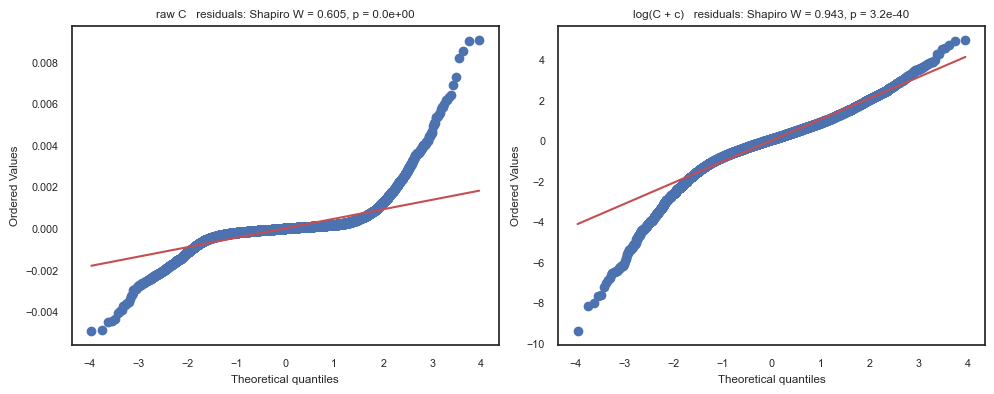

In [83]:
# RM-ANOVA assumes normal residuals after removing subject and condition means.
import scipy.stats as sps
_factors = ['Caudate_Putamen', 'Rostral_Caudal', 'Cortex_ROI', 'hemisphere']

def _rm_resid(df):
    y = df['Connectivity'].to_numpy(float)
    y = y - df.groupby('participant_id')['Connectivity'].transform('mean').to_numpy()
    cell = df[_factors].astype(str).agg('-'.join, axis=1).to_numpy()
    return y - pd.Series(y).groupby(cell).transform('mean').to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (frame, tag) in zip(axes,
                            [(all_long_df.dropna(subset=['Connectivity']), 'raw C'),
                             (all_log_df, 'log(C + c)')]):
    r = _rm_resid(frame)
    r = r[np.isfinite(r)]
    sps.probplot(r, plot=ax)
    _r = r if len(r) <= 5000 else np.random.default_rng(0).choice(r, 5000, replace=False)
    W, p = sps.shapiro(_r)
    ax.set_title(f'{tag}   residuals: Shapiro W = {W:.3f}, p = {p:.1e}')
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'residual_qq_raw_vs_log.svg'))


In [84]:
# omnibus ANOVAs on the log scale.  >2 within-factors -> AnovaRM; 2 -> rm_anova.
def _omnibus_log(df, within, label):
    if len(within) > 2:
        aov = AnovaRM(df, aggregate_func='mean', depvar='Connectivity',
                      subject='participant_id', within=within).fit()
        return export_anova(aov, label, STATS_OUT_DIR)
    d = df.groupby(['participant_id'] + within, as_index=False)['Connectivity'].mean()
    aov = pg.rm_anova(data=d, dv='Connectivity', within=within,
                      subject='participant_id', detailed=True, effsize='np2')
    return export_anova(aov, label, STATS_OUT_DIR)

_specs = [
    (aud_log_df, ['Caudate_Putamen', 'Rostral_Caudal', 'Cortex_ROI', 'hemisphere'], 'aud_full_log'),
    (aud_log_df, ['Caudate_Putamen', 'Rostral_Caudal', 'Cortex_ROI'],               'aud_cau_rostral_roi_log'),
    (aud_log_df, ['Cortex_ROI', 'Caudate_Putamen'],                                 'aud_roi_cau_log'),
    (aud_log_df, ['Cortex_ROI', 'Rostral_Caudal'],                                  'aud_roi_rostral_log'),
    (pfc_log_df, ['Caudate_Putamen', 'Rostral_Caudal', 'Cortex_ROI', 'hemisphere'], 'pfc_full_log'),
    (pfc_log_df, ['Caudate_Putamen', 'Rostral_Caudal', 'Cortex_ROI'],               'pfc_cau_rostral_roi_log'),
    (pfc_log_df, ['Cortex_ROI', 'Caudate_Putamen'],                                 'pfc_roi_cau_log'),
    (pfc_log_df, ['Cortex_ROI', 'Rostral_Caudal'],                                  'pfc_roi_rostral_log'),
]
for _df, _within, _lbl in _specs:
    print(f'\n=== {_lbl} ===')
    display(_omnibus_log(_df, _within, _lbl))



=== aud_full_log ===
  (SVD fallback: gesdd failed, retrying with gesvd)


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Caudate_Putamen,1953.69,1.0,99.0,p < .001,,,,"F(1, 99) = 1953.69, p < .001"
1,Rostral_Caudal,578.45,1.0,99.0,p < .001,,,,"F(1, 99) = 578.45, p < .001"
2,Cortex_ROI,661.84,4.0,396.0,p < .001,,,,"F(4, 396) = 661.84, p < .001"
3,hemisphere,50.77,1.0,99.0,p < .001,,,,"F(1, 99) = 50.77, p < .001"
4,Caudate_Putamen:Rostral_Caudal,251.68,1.0,99.0,p < .001,,,,"F(1, 99) = 251.68, p < .001"
5,Caudate_Putamen:Cortex_ROI,65.97,4.0,396.0,p < .001,,,,"F(4, 396) = 65.97, p < .001"
6,Rostral_Caudal:Cortex_ROI,48.79,4.0,396.0,p < .001,,,,"F(4, 396) = 48.79, p < .001"
7,Caudate_Putamen:hemisphere,4.59,1.0,99.0,p = .035,,,,"F(1, 99) = 4.59, p = .035"
8,Rostral_Caudal:hemisphere,23.59,1.0,99.0,p < .001,,,,"F(1, 99) = 23.59, p < .001"
9,Cortex_ROI:hemisphere,88.05,4.0,396.0,p < .001,,,,"F(4, 396) = 88.05, p < .001"



=== aud_cau_rostral_roi_log ===


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Caudate_Putamen,1953.69,1.0,99.0,p < .001,,,,"F(1, 99) = 1953.69, p < .001"
1,Rostral_Caudal,578.45,1.0,99.0,p < .001,,,,"F(1, 99) = 578.45, p < .001"
2,Cortex_ROI,661.84,4.0,396.0,p < .001,,,,"F(4, 396) = 661.84, p < .001"
3,Caudate_Putamen:Rostral_Caudal,251.68,1.0,99.0,p < .001,,,,"F(1, 99) = 251.68, p < .001"
4,Caudate_Putamen:Cortex_ROI,65.97,4.0,396.0,p < .001,,,,"F(4, 396) = 65.97, p < .001"
5,Rostral_Caudal:Cortex_ROI,48.79,4.0,396.0,p < .001,,,,"F(4, 396) = 48.79, p < .001"
6,Caudate_Putamen:Rostral_Caudal:Cortex_ROI,126.57,4.0,396.0,p < .001,,,,"F(4, 396) = 126.57, p < .001"



=== aud_roi_cau_log ===


...

,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Caudate_Putamen,20.79,1.0,99.0,p < .001,,,,"F(1, 99) = 20.79, p < .001"
1,Rostral_Caudal,754.55,1.0,99.0,p < .001,,,,"F(1, 99) = 754.55, p < .001"
2,Cortex_ROI,451.79,4.0,396.0,p < .001,,,,"F(4, 396) = 451.79, p < .001"
3,Caudate_Putamen:Rostral_Caudal,0.99,1.0,99.0,p = .323,,,,"F(1, 99) = 0.99, p = .323"
4,Caudate_Putamen:Cortex_ROI,377.44,4.0,396.0,p < .001,,,,"F(4, 396) = 377.44, p < .001"
5,Rostral_Caudal:Cortex_ROI,839.18,4.0,396.0,p < .001,,,,"F(4, 396) = 839.18, p < .001"
6,Caudate_Putamen:Rostral_Caudal:Cortex_ROI,176.56,4.0,396.0,p < .001,,,,"F(4, 396) = 176.56, p < .001"



=== pfc_roi_cau_log ===


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Cortex_ROI,451.79,4,396,p < .001,p < .001,0.820,0.514,"F(2.05, 203.41) = 451.79, p < .001 (GG ε=0.51)..."
1,Caudate_Putamen,20.79,1,99,p < .001,p < .001,0.174,1.000,"F(1, 99) = 20.79, p < .001, ηp² = .17"
2,Cortex_ROI * Caudate_Putamen,377.44,4,396,p < .001,p < .001,0.792,0.694,"F(2.78, 274.79) = 377.44, p < .001 (GG ε=0.69)..."



=== pfc_roi_rostral_log ===


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Cortex_ROI,451.79,4,396,p < .001,p < .001,0.820,0.514,"F(2.05, 203.41) = 451.79, p < .001 (GG ε=0.51)..."
1,Rostral_Caudal,754.55,1,99,p < .001,p < .001,0.884,1.000,"F(1, 99) = 754.55, p < .001, ηp² = .88"
2,Cortex_ROI * Rostral_Caudal,839.18,4,396,p < .001,p < .001,0.894,0.610,"F(2.44, 241.66) = 839.18, p < .001 (GG ε=0.61)..."


## Anatomical Connectivity Figure (Yeterian & Pandya 1998 Style)

Schematic figure showing auditory corticostriatal connectivity on a lateral brain view and coronal striatal cross-sections.


In [85]:
import os

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import PathPatch, FancyArrowPatch
from matplotlib.path import Path
import matplotlib.patches as mpatches
import nibabel as nib
from skimage import measure
import seaborn as sns

In [86]:
# Per-ROI mask files (from atlas_construction.ipynb) + an MNI brain mask.
atlas_dir = os.path.join('/Users/dsj3886/data_local/derivatives/',
                         'atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal/')
file_prefix = 'atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal'

BRAIN_MASK_PATH = os.path.join('/Users/dsj3886/data_local/reference/',
                               'mni_icbm152_nlin_asym_09c_nifti/mni_icbm152_nlin_asym_09c/',
                               'mni_icbm152_t1_tal_nlin_asym_09c_mask.nii')

AUDITORY_MASK_PATHS = {
    "HG":   os.path.join(atlas_dir, f'{file_prefix}_L-HG.nii.gz'),
    "PP":   os.path.join(atlas_dir, f'{file_prefix}_L-PP.nii.gz'),
    "PT":   os.path.join(atlas_dir, f'{file_prefix}_L-PT.nii.gz'),
    "STGa": os.path.join(atlas_dir, f'{file_prefix}_L-STGa.nii.gz'),
    "STGp": os.path.join(atlas_dir, f'{file_prefix}_L-STGp.nii.gz'),
}

PREFRONTAL_MASK_PATHS = {
    "OFC":   os.path.join(atlas_dir, f'{file_prefix}_L-OFC.nii.gz'),
    "ACC":   os.path.join(atlas_dir, f'{file_prefix}_L-ACC.nii.gz'),
    "FMC":   os.path.join(atlas_dir, f'{file_prefix}_L-FMC.nii.gz'),
    "MFG":   os.path.join(atlas_dir, f'{file_prefix}_L-MFG.nii.gz'),
    "IFGt":  os.path.join(atlas_dir, f'{file_prefix}_L-IFGt.nii.gz'),
    "IFGo":  os.path.join(atlas_dir, f'{file_prefix}_L-IFGo.nii.gz'),
    "PreCG": os.path.join(atlas_dir, f'{file_prefix}_L-PreCG.nii.gz'),
}

STRIATAL_MASK_PATHS = {
    "aPUT": os.path.join(atlas_dir, f'{file_prefix}_aPUT-lh.nii.gz'),
    "pPUT": os.path.join(atlas_dir, f'{file_prefix}_pPUT-lh.nii.gz'),
    "aCAU": os.path.join(atlas_dir, f'{file_prefix}_aCAU-lh.nii.gz'),
    "pCAU": os.path.join(atlas_dir, f'{file_prefix}_pCAU-lh.nii.gz'),
}


In [87]:
def get_roi_contour(mask_path, axis=1, slice_idx=None):
    """
    Load a binary NIfTI mask and return the largest 2D contour from a slice.

    axis=0 -> sagittal slice
    axis=1 -> coronal slice
    slice_idx: if None, use the slice with the largest cross-sectional area.
    """
    data = nib.load(mask_path).get_fdata()
    if slice_idx is None:
        areas = [np.take(data, i, axis=axis).sum() for i in range(data.shape[axis])]
        slice_idx = int(np.argmax(areas))
    slice_2d = np.take(data, slice_idx, axis=axis)
    contours = measure.find_contours(slice_2d, level=0.5)
    return max(contours, key=len)


def get_best_slice_idx(mask_path, axis):
    """Return the slice index with the largest mask area along the given axis."""
    data = nib.load(mask_path).get_fdata()
    areas = [np.take(data, i, axis=axis).sum() for i in range(data.shape[axis])]
    return int(np.argmax(areas))


In [88]:

CORTEX_ROI      = 'HG'   # highlighted in the brain panel

all_conn = (
    all_long_df[all_long_df['Cortex_ROI'].isin(CORTEX_ROIS)]
    .groupby(['Cortex_ROI', 'Striatum_ROI'])['Connectivity']
    .mean()
    .reset_index()
    .rename(columns={'Connectivity': 'conn_mean'})
)
print(all_conn)


   Cortex_ROI Striatum_ROI  conn_mean
0         ACC         aCAU   0.000394
1         ACC         aPUT   0.000019
2         ACC         pCAU   0.000034
3         ACC         pPUT   0.000010
4         FMC         aCAU   0.000188
5         FMC         aPUT   0.000147
6         FMC         pCAU   0.000007
7         FMC         pPUT   0.000006
8          HG         aCAU   0.000005
9          HG         aPUT   0.000064
10         HG         pCAU   0.000011
11         HG         pPUT   0.001446
12       IFGo         aCAU   0.000177
13       IFGo         aPUT   0.000109
14       IFGo         pCAU   0.001386
15       IFGo         pPUT   0.000359
16       IFGt         aCAU   0.000394
17       IFGt         aPUT   0.000470
18       IFGt         pCAU   0.000476
19       IFGt         pPUT   0.000139
20        OFC         aCAU   0.000250
21        OFC         aPUT   0.002395
22        OFC         pCAU   0.000096
23        OFC         pPUT   0.000396
24         PP         aCAU   0.000038
25         P

In [89]:
from matplotlib.colors import Normalize as MplNorm, LogNorm, to_rgb
from matplotlib.cm import ScalarMappable

CMAP = plt.cm.YlOrRd

AUDITORY_PALETTE = {
    'HG':   CMAP(0.85),
    'PP':   '#5aafe0',
    'PT':   '#78c679',
    'STGa': '#9970ab',
    'STGp': '#d9a63a',
}

PREFRONTAL_PALETTE = {
    'OFC':   '#e8a838',
    'ACC':   '#d46b6b',
    'FMC':   '#8e5fbf',
    'MFG':   '#4d9de0',
    'IFGt':  '#3bb273',
    'IFGo':  '#e84855',
    'PreCG': '#7f8c8d',
}

# Paint order: last = highest priority (drawn on top).
# Auditory (temporal plane) are given priority over prefrontal.
PAINT_ORDER = ['PreCG', 'IFGo', 'IFGt', 'MFG', 'FMC', 'ACC', 'OFC',
               'STGp', 'STGa', 'PT', 'PP', 'HG']

# Z-shear applied before Y-Z projection.
# Positive value: each voxel at X=x is shifted +x*SHEAR_FACTOR in Z.
# This tilts the projection to look from slightly below, separating the
# superior temporal plane (HG/PP/PT, deeper/more medial) from the lateral
# surface (STGa/STGp, more lateral).
SHEAR_FACTOR = 0.3


def _sheared_footprint(mask_3d, shear_factor, out_nz):
    """Y-Z footprint with Z-shear. Returns bool array (ny, out_nz)."""
    nx, ny, nz = mask_3d.shape
    result = np.zeros((ny, out_nz), dtype=bool)
    for x in range(nx):
        z_shift = int(round(x * shear_factor))
        sl = mask_3d[x] > 0          # (ny, nz)
        src_end = min(nz, out_nz - z_shift)
        dst_start = z_shift
        if src_end > 0 and dst_start < out_nz:
            result[:, dst_start:dst_start + src_end] |= sl[:, :src_end]
    return result


def _make_surface_rgba(brain_mask_path, roi_mask_paths, palette):
    """
    Sheared Y-Z footprint per ROI painted in PAINT_ORDER.
    Returns (rgba (nz_out,ny,4), brain_proj (ny,nz_out), roi_label (ny,nz_out), roi_list).
    """
    brain_data = nib.load(brain_mask_path).get_fdata() > 0
    nx, ny, nz = brain_data.shape
    nz_out = nz + int(nx * SHEAR_FACTOR) + 2   # extra Z room after shearing

    brain_proj = _sheared_footprint(brain_data, SHEAR_FACTOR, nz_out)

    footprints = {
        roi: _sheared_footprint(nib.load(path).get_fdata(), SHEAR_FACTOR, nz_out)
        for roi, path in roi_mask_paths.items()
    }

    rgba = np.zeros((nz_out, ny, 4), dtype=float)
    in_brain = brain_proj.T
    rgba[in_brain, :3] = 0.85
    rgba[in_brain,  3] = 1.0

    roi_list  = list(roi_mask_paths.keys())
    roi_label = np.zeros((ny, nz_out), dtype=int)

    for roi in PAINT_ORDER:
        if roi not in footprints:
            continue
        fp   = footprints[roi]
        mask = fp.T
        rgba[mask, :3] = to_rgb(palette.get(roi, '#888888'))
        rgba[mask,  3] = 1.0
        roi_label[fp] = roi_list.index(roi) + 1

    rgba[~in_brain, 3] = 0.0
    return rgba, brain_proj, roi_label, roi_list, footprints


def draw_brain_panel(ax, brain_mask_path, cortex_mask_paths, striatal_mask_paths):
    combined_palette = {**AUDITORY_PALETTE, **PREFRONTAL_PALETTE}
    rgba, brain_proj, roi_label, roi_list, footprints = _make_surface_rgba(
        brain_mask_path, cortex_mask_paths, combined_palette)

    ny, nz_out = brain_proj.shape
    ax.imshow(rgba, origin='lower', extent=[0, ny, 0, nz_out],
              aspect='equal', interpolation='nearest')

    # Brain silhouette
    brain_contour = max(measure.find_contours(brain_proj.astype(float), level=0.5), key=len)
    ax.plot(brain_contour[:, 0], brain_contour[:, 1], color='black', linewidth=1.5, zorder=4)

    # ROI boundary contours
    for roi, fp in footprints.items():
        contours = measure.find_contours(fp.astype(float), level=0.5)
        for c in contours:
            ax.plot(c[:, 0], c[:, 1], color='black', linewidth=0.6, zorder=5)

    # Labels at painted centroid
    for idx, roi in enumerate(roi_list, start=1):
        ys, zs = np.where(roi_label == idx)
        if len(ys) == 0:
            continue
        is_active = (roi == CORTEX_ROI)
        ax.text(ys.mean(), zs.mean(), _display_label(roi),
                ha='center', va='center', fontsize=7, zorder=6,
                fontweight='bold' if is_active else 'normal',
                color='white' if is_active else 'black')

    # Crop to brain bounding box
    ys, zs = np.where(brain_proj)
    margin = 4
    ax.set_xlim(ys.min() - margin, ys.max() + margin)
    ax.set_ylim(zs.min() - margin, zs.max() + margin)
    ax.set_aspect('equal')
    ax.invert_xaxis()

    ax.axis('off')


def draw_striatal_structure(ax, roi_ant, roi_post, hg_conn_df, striatal_mask_paths, norm, title=None):
    data_ant  = nib.load(striatal_mask_paths[roi_ant]).get_fdata()
    data_post = nib.load(striatal_mask_paths[roi_post]).get_fdata()
    slice_idx = int(np.argmax((data_ant + data_post).sum(axis=(1, 2))))

    for roi, data in [(roi_ant, data_ant), (roi_post, data_post)]:
        row      = hg_conn_df[hg_conn_df["Striatum_ROI"] == roi]
        conn_val = float(row["conn_mean"].values[0]) if not row.empty else 0
        contours = measure.find_contours(data[slice_idx, :, :], level=0.5)
        if not contours:
            continue
        contour = max(contours, key=len)
        verts = np.column_stack([contour[:, 0], contour[:, 1]])
        codes  = [Path.MOVETO] + [Path.LINETO] * (len(verts) - 2) + [Path.CLOSEPOLY]
        ax.add_patch(PathPatch(Path(verts, codes),
                               facecolor=CMAP(norm(conn_val)),
                               edgecolor='black', linewidth=1.5))
        label = 'ant' if roi == roi_ant else 'post'
        ax.text(np.mean(contour[:, 0]), np.mean(contour[:, 1]), label,
                ha='center', va='center', fontsize=6, color='black', alpha=0.7)

    if title:
        ax.set_title(title, fontsize=10)
    ax.set_aspect('equal')
    ax.autoscale()
    # Tighten limits to the data so no internal whitespace inflates the gap
    margin = 3
    ax.set_xlim(ax.get_xlim()[0] - margin, ax.get_xlim()[1] + margin)
    ax.set_ylim(ax.get_ylim()[0] - margin, ax.get_ylim()[1] + margin)
    ax.invert_xaxis()
    ax.axis('off')


In [ ]:
# -- Build figure: auditory + prefrontal striatal panels ---------------------
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable

vmax     = float(all_conn['conn_mean'].max())
vmin_log = float(all_conn.loc[all_conn['conn_mean'] > 0, 'conn_mean'].min())
norm     = LogNorm(vmin=vmin_log, vmax=vmax)

col_w = 1.8
fig_w = col_w * max(len(AUDITORY_ROIS), len(PREFRONTAL_ROIS))
fig   = plt.figure(figsize=(fig_w, 7.7))

# Outer grid: auditory (cau+put) | prefrontal (cau+put)
gs_outer = gridspec.GridSpec(2, 1, height_ratios=[1.8, 1.8], hspace=0.3)

# ── Auditory section ─────────────────────────────────────────────────────────
gs_aud = gridspec.GridSpecFromSubplotSpec(
    2, len(AUDITORY_ROIS), subplot_spec=gs_outer[0], wspace=0.06, hspace=0.15)

ax_cau_aud_first = ax_put_aud_first = None
aud_cau_axes = []
for col, roi in enumerate(AUDITORY_ROIS):
    conn_df = all_conn[all_conn['Cortex_ROI'] == roi]
    ax_cau = fig.add_subplot(gs_aud[0, col])
    ax_put = fig.add_subplot(gs_aud[1, col])
    if col == 0:
        ax_cau_aud_first = ax_cau
        ax_put_aud_first = ax_put
    draw_striatal_structure(ax_cau, 'aCAU', 'pCAU', conn_df, STRIATAL_MASK_PATHS, norm)
    draw_striatal_structure(ax_put, 'aPUT', 'pPUT', conn_df, STRIATAL_MASK_PATHS, norm)
    ax_cau.set_title(roi, fontsize=9)
    aud_cau_axes.append(ax_cau)

ax_cau_aud_first.annotate('Caudate', xy=(0, 0.5), xycoords='axes fraction',
                           xytext=(-8, 0), textcoords='offset points',
                           ha='right', va='center', fontsize=9, rotation=90)
ax_put_aud_first.annotate('Putamen', xy=(0, 0.5), xycoords='axes fraction',
                           xytext=(-8, 0), textcoords='offset points',
                           ha='right', va='center', fontsize=9, rotation=90)

# ── Prefrontal section ───────────────────────────────────────────────────────
gs_pfc = gridspec.GridSpecFromSubplotSpec(
    2, len(PREFRONTAL_ROIS), subplot_spec=gs_outer[1], wspace=0.06, hspace=0.15)

ax_cau_pfc_first = ax_put_pfc_first = None
for col, roi in enumerate(PREFRONTAL_ROIS):
    conn_df = all_conn[all_conn['Cortex_ROI'] == roi]
    ax_cau = fig.add_subplot(gs_pfc[0, col])
    ax_put = fig.add_subplot(gs_pfc[1, col])
    if col == 0:
        ax_cau_pfc_first = ax_cau
        ax_put_pfc_first = ax_put
    draw_striatal_structure(ax_cau, 'aCAU', 'pCAU', conn_df, STRIATAL_MASK_PATHS, norm)
    draw_striatal_structure(ax_put, 'aPUT', 'pPUT', conn_df, STRIATAL_MASK_PATHS, norm)
    ax_cau.set_title(_display_label(roi), fontsize=9)

ax_cau_pfc_first.annotate('Caudate', xy=(0, 0.5), xycoords='axes fraction',
                            xytext=(-8, 0), textcoords='offset points',
                            ha='right', va='center', fontsize=9, rotation=90)
ax_put_pfc_first.annotate('Putamen', xy=(0, 0.5), xycoords='axes fraction',
                            xytext=(-8, 0), textcoords='offset points',
                            ha='right', va='center', fontsize=9, rotation=90)

# ── Section labels ────────────────────────────────────────────────────────────
fig.canvas.draw()
# Section label sits above the row of column titles (e.g. HG for auditory),
# not just above the bare axes -- measure the titles' actual rendered top
# (they vary with fontsize/dpi) rather than guessing a fixed fig-fraction pad,
# which previously undershot and let 'Auditory' overlap whichever ROI landed
# in the middle column.
renderer = fig.canvas.get_renderer()
aud_title_top = max(
    ax.title.get_window_extent(renderer).transformed(fig.transFigure.inverted()).y1
    for ax in aud_cau_axes
)
aud_label_y = aud_title_top + 0.01
pfc_label_y = (ax_cau_pfc_first.get_position().y1 + ax_put_aud_first.get_position().y0) / 2
fig.text(0.5, aud_label_y, 'Auditory',   ha='center', va='bottom', fontsize=10, style='italic')
fig.text(0.5, pfc_label_y, 'Prefrontal', ha='center', va='center', fontsize=10, style='italic')

# ── Shared colorbar ──────────────────────────────────────────────────────────
sm = ScalarMappable(cmap=CMAP, norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.93, 0.2, 0.012, 0.25])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('connectivity (a.u. / mm³)', fontsize=8)

fig.suptitle('Corticostriatal connectivity', fontsize=12, y=1.01)

fig.savefig(os.path.join(FIGURES_DIR, 'corticostriatal_connectivity_schematic.pdf'), bbox_inches='tight', dpi=300)
fig.savefig(os.path.join(FIGURES_DIR, 'corticostriatal_connectivity_schematic.png'), bbox_inches='tight', dpi=300)
fig.savefig(os.path.join(FIGURES_DIR, 'corticostriatal_connectivity_schematic.svg'), bbox_inches='tight', dpi=300)
plt.show()


### Surface ROI visualisation (Destrieux approximation)

Renders the auditory / prefrontal ROIs on an fsaverage surface for figure panels. Uses approximate Destrieux labels, independent of the connectivity analysis.

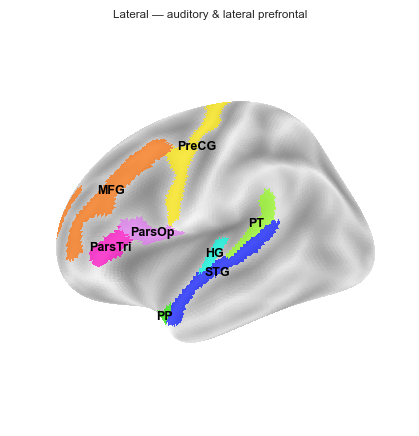

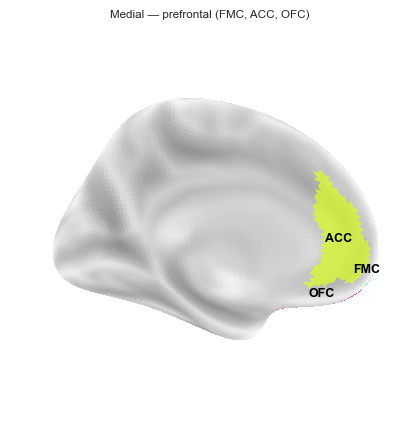

In [91]:
from nilearn import datasets, plotting, surface
import numpy as np

destrieux = datasets.fetch_atlas_surf_destrieux()
fsaverage = datasets.fetch_surf_fsaverage('fsaverage5')

labels = [l.decode() if isinstance(l, bytes) else l for l in destrieux['labels']]
parc   = destrieux['map_left']
coords, _ = surface.load_surf_mesh(fsaverage['infl_left'])

# ROI → Destrieux label
auditory_destrieux = {
    'STG':  'G_temp_sup-Lateral',
    'HG':   'G_temp_sup-G_T_transv',
    'PP':   'G_temp_sup-Plan_polar',
    'PT':   'G_temp_sup-Plan_tempo',
}
lateral_pfc_destrieux = {
    'PreCG': 'G_precentral',
    'MFG':   'G_front_middle',
    'IFGt':  'G_front_inf-Triangul',
    'IFGo':  'G_front_inf-Opercular',
}
medial_pfc_destrieux = {
    'FMC': 'G_and_S_frontomargin',
    'ACC': 'G_and_S_cingul-Ant',
    'OFC': 'G_orbital',
}


def make_roi_map(roi_dict):
    roi_map = np.zeros(len(parc))
    for roi_id, label in enumerate(roi_dict.values(), start=1):
        idx = labels.index(label)
        roi_map[parc == idx] = roi_id
    return roi_map


def add_labels(ax, roi_map, roi_dict):
    for roi_id, name in enumerate(roi_dict.keys(), start=1):
        verts = np.where(roi_map == roi_id)[0]
        if len(verts) == 0:
            continue
        cx, cy, cz = coords[verts].mean(axis=0)
        ax.text(cx, cy, cz, _display_label(name), fontsize=9, fontweight='bold',
                ha='center', va='center', color='black',
                bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.))


# ── Lateral view: auditory + lateral prefrontal ───────────────────────────────
lateral_rois    = {**auditory_destrieux, **lateral_pfc_destrieux}
roi_map_lateral = make_roi_map(lateral_rois)

fig_lat = plotting.plot_surf_roi(
    fsaverage['infl_left'],
    roi_map=roi_map_lateral,
    bg_map=fsaverage['sulc_left'],
    bg_on_data=True,
    darkness=0.5,
    view='lateral',
    title='Lateral — auditory & lateral prefrontal',
)
add_labels(fig_lat.axes[0], roi_map_lateral, lateral_rois)

# ── Medial view: medial/orbital prefrontal ────────────────────────────────────
roi_map_medial = make_roi_map(medial_pfc_destrieux)

fig_med = plotting.plot_surf_roi(
    fsaverage['infl_left'],
    roi_map=roi_map_medial,
    bg_map=fsaverage['sulc_left'],
    bg_on_data=True,
    darkness=0.5,
    view='medial',
    title='Medial — prefrontal (FMC, ACC, OFC)',
)
add_labels(fig_med.axes[0], roi_map_medial, medial_pfc_destrieux)


In [92]:
import os 
atlas_fpath = os.path.join('/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal/',
                           'atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal_atlas_space-MNI152NLin6Asym.nii.gz')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from nilearn.plotting import view_img_on_surf
import nibabel as nib

# Keep subcortical (1-8), auditory (9-18), and selected prefrontal only.
# Zero out visual (41-54) and excluded prefrontal ROIs.
pfc_to_keep = {'L-' + r for r in PREFRONTAL_ROIS} | {'R-' + r for r in PREFRONTAL_ROIS}

atlas_img  = nib.load(atlas_fpath)
atlas_data = atlas_img.get_fdata().copy()
for label_idx, label_name in enumerate(region_list, start=1):
    if label_idx >= 41 or (19 <= label_idx <= 40 and label_name not in pfc_to_keep) or label_name.startswith('R-'):
        atlas_data[atlas_data == label_idx] = 0

# Remap surviving labels to a dense 1..k range -- raw label indices (up to 37)
# leave ~9 unused gaps from zeroed-out regions, so the hue wheel below was
# being split into more slices than there are visible regions, packing real
# colors closer together than necessary.
present = sorted(int(v) for v in np.unique(atlas_data) if v > 0)
remap = {old: new for new, old in enumerate(present, start=1)}
remapped = np.zeros_like(atlas_data)
for old_idx, new_idx in remap.items():
    remapped[atlas_data == old_idx] = new_idx
atlas_data = remapped

masked_img = nib.Nifti1Image(atlas_data.astype(np.float32), atlas_img.affine, atlas_img.header)
n_labels = len(present)

# Evenly-spaced hues (HUSL) at fixed saturation/lightness -- guarantees a
# minimum hue separation between all n_labels colors (no near-duplicate
# "browns") and stays off white/black by construction (unlike randomly
# sampling from tab20/tab20b/tab20c, which include pale and near-duplicate
# earth-tone entries). husl assigns hues in index order, so labels that are
# close together in the LUT (e.g. HG-PP-PT-STGa-STGp = 9-13, or ACC/OFC =
# 35/37) get near-adjacent hues and read as one blob even though they're
# spatially adjacent, distinct regions -- shuffle the hue assignment (fixed
# seed) so index-neighbors don't get color-neighbors.
# Hue-shuffling alone can't raise the *minimum* pairwise hue distance -- with
# n_labels evenly-spaced hues, some pair is always exactly one hue-step apart
# no matter how they're assigned (all slots are used). Alternate lightness by
# hue-slot position so whichever two labels land on adjacent hues (unavoidable)
# still differ visibly in brightness, independent of shuffle luck.
_hues_dark  = sns.husl_palette(n_labels, l=0.45)
_hues_light = sns.husl_palette(n_labels, l=0.72)
_hues = [(_hues_dark if i % 2 == 0 else _hues_light)[i] for i in range(n_labels)]
_perm = np.random.default_rng(0).permutation(n_labels)
cmap_rois = ListedColormap([_hues[i] for i in _perm])

view = view_img_on_surf(
    stat_map_img=masked_img,
    surf_mesh="fsaverage",
    threshold=0.5,
    cmap=cmap_rois,
    vmin=1,
    vmax=n_labels,
    vol_to_surf_kwargs={
        "n_samples": 1,
        "radius": 3,
        "interpolation": "nearest",
    },
    symmetric_cmap=False,
    colorbar=False,
)

#view  # interactive; save manually, then clear this output (keeps the notebook small)


In [96]:
# Static, savable re-render of the interactive view above, sampling the SAME
# volumetric atlas. Uses inner_mesh (white matter surface) rather than a
# radius-ball, so each vertex's sample stays within the local cortical ribbon
# instead of jumping across sulcal folds into an unrelated gyrus (visible
# earlier as speckled/interdigitated regions, worst medially). n_samples=1
# keeps it a single nearest-voxel lookup per vertex -- averaging across depth
# samples would be meaningless for discrete integer labels.
texture = surface.vol_to_surf(
    masked_img, fsaverage['pial_left'],
    inner_mesh=fsaverage['white_left'],
    interpolation='nearest',
    n_samples=1,
)

_views = ['lateral', 'medial', 'dorsal', 'ventral', 'anterior', 'posterior']
for _view in _views:
    _fig = plotting.plot_surf_roi(
        fsaverage['infl_left'], roi_map=texture, hemi='left', view=_view,
        bg_map=fsaverage['sulc_left'], bg_on_data=True, darkness=0.5,
        cmap=cmap_rois, vmin=1, vmax=n_labels,
        title=f'Atlas ROIs -- {_view}',
    )
    _fig.savefig(os.path.join(FIGURES_DIR, f'atlas_surface_{_view}.png'), dpi=300, bbox_inches='tight')
    plt.close(_fig)

print(f'saved {len(_views)} static views to {FIGURES_DIR}/atlas_surface_*.png')


saved 6 static views to figures/atlas_surface_*.png


In [97]:
import numpy as np
vals, counts = np.unique(texture, return_counts=True)
for v, n in zip(vals, counts):
    if v > 0:
        print(f'label {int(v):3d}  {region_list[int(v)-1]:8s}  {n} vertices  color={cmap_rois(int(v)/n_labels)}')


label   9  L-HG      55 vertices  color=(0.8684405700976466, 0.4330820812972043, 0.9577935099582316, 1.0)
label  10  L-PP      90 vertices  color=(0.8455015830388781, 0.5451434996609393, 0.19534396548634997, 1.0)
label  11  L-PT      140 vertices  color=(0.6423044349219739, 0.5497680051256467, 0.9582651433656727, 1.0)
label  12  L-STGa    33 vertices  color=(0.5105309046900421, 0.6614299289084904, 0.1930849118538962, 1.0)
label  13  L-STGp    70 vertices  color=(0.9677975592919913, 0.44127456009157356, 0.5358103155058701, 1.0)
label  19  L-FP      84 vertices  color=(0.7154343001494793, 0.602730520228011, 0.19429856739332513, 1.0)
label  21  L-SFG     89 vertices  color=(0.21044753832183283, 0.6773105080456748, 0.6433941168468681, 1.0)
label  23  L-MFG     47 vertices  color=(0.3826123880541, 0.6840567520057004, 0.19257547490713436, 1.0)
label  24  R-MFG     5 vertices  color=(0.9617766053939635, 0.3934528472201152, 0.8193188819263119, 1.0)
label  25  L-IFGt    228 vertices  color=(0.9